# FHE Showcase — companion notebook to the *Overview of FHE* slides

This notebook reproduces the constructions from the slides with runnable code.
Sections 0–3 use plain numpy, so every number can be traced by hand and matches the slides.
Section 4 switches to OpenFHE, built from the local `../openfhe` checkout, for real-size CKKS.
Each section starts with one **helper cell** (functions only); the cells after it show just the steps.

<a id="contents"></a>**Contents**

- **[0. Lattices and their hard problems](#s0)**
    - [0.1 One lattice, two bases](#s0-1)
    - [0.2 Shortest Vector Problem (SVP)](#s0-2)
    - [0.3 Short Integer Solution (SIS)](#s0-3)
    - [0.4 A higher-dimensional problem, solved by exponential search](#s0-4)
- **[1. LWE and Ring-LWE](#s1)**
    - [1.1 What an LWE instance looks like](#s1-1)
    - [1.2 Private-key encryption from LWE (Regev)  — *slide 28*](#s1-2)
    - [1.3 Computing on the ciphertexts: add and multiply](#s1-3)
    - [1.4 Ring-LWE: one sample carries $N$ LWE samples](#s1-4)
    - [1.5 Summary](#s1-5)
- **[2. The math toolbox: $\mathbb Z_q$, roots of unity, CRT and the NTT](#s2)**
    - [2.1 Tools 1–2: $\mathbb Z_q$ and the ring $\mathcal R_q=\mathbb Z_q[X]/(X^N+1)$](#s2-1)
    - [2.2 Tool 3: roots of unity, complex and modular](#s2-2)
    - [2.3 Tool 4: the Chinese Remainder Theorem, and RNS](#s2-3)
    - [2.4 Tool 5: from the DFT to the NTT (*worked example 2/4*)](#s2-4)
    - [2.5 The NTT *is* the CRT of polynomials: butterflies (*worked examples 3/4 and 4/4*)](#s2-5)
    - [2.6 RNS + NTT = double-CRT](#s2-6)
- **[3. CKKS, step by step](#s3)**
    - [3.1 Encoding: slots $\to$ polynomial (the canonical embedding)](#s3-1)
    - [3.2 Slots are SIMD lanes](#s3-2)
    - [3.3 The scale $\Delta$: fixed-point precision](#s3-3)
    - [3.4 The toy workflow, end to end (*Example workflow* and *Workflow 1–5*)](#s3-4)
    - [3.5 Rotation: a cheap permutation plus a key switch](#s3-5)
    - [3.6 The cross-limb kernels: ModUp, ModDown, Rescale](#s3-6)
    - [3.7 Summary and next step](#s3-7)
- **[4. CKKS at real parameters with OpenFHE](#s4)**
    - [4.0 Setup: which OpenFHE this uses](#s4-0)
    - [4.1 Depth decides the parameters](#s4-1)
    - [4.2 A real-size round trip](#s4-2)
    - [4.3 Operations and levels](#s4-3)
    - [4.4 How big are ciphertexts and keys?](#s4-4)
    - [4.5 Timing on this laptop, and what it costs](#s4-5)
    - [4.6 Bootstrapping](#s4-6)

> **These parameters are for teaching only.** They are the right *size*, but the code is not constant-time
> and uses numpy's RNG, which is not cryptographically secure. Do not use it to protect real data.

In [75]:
import itertools, time
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)          # fixed seed -> reproducible numbers

# ---- sampling and modular arithmetic (used everywhere)
def centered(x, q):
    # Map residues mod q to the centered range (-q/2, q/2].
    x = np.mod(x, q)
    return np.where(x > q // 2, x - q, x)

def uniform(shape, q):                     # a <- Z_q
    return rng.integers(0, q, size=shape, dtype=np.int64)

def ternary(shape):                        # s <- {-1, 0, 1}
    return rng.integers(-1, 2, size=shape, dtype=np.int64)

def gaussian(shape, sigma=3.19):           # e <- rounded Gaussian (sigma = 3.19, as in OpenFHE)
    return np.rint(rng.normal(0.0, sigma, size=shape)).astype(np.int64)

def budget_bits(noise, q):
    # Remaining noise budget: how many more doublings of |noise| fit below q/4.
    return np.log2((q / 4) / max(1, int(np.max(np.abs(noise)))))

# ---- timing, exponent fitting, printing (used everywhere)
def timed(fn, *args):
    # Run fn(*args) once; return (result, seconds).
    t0 = time.perf_counter()
    out = fn(*args)
    return out, time.perf_counter() - t0

def fit_growth(xs, seconds):
    # Fit log2(seconds) = a*x + b; the growth per unit of x is 2**a.
    a, b = np.polyfit(np.asarray(xs, dtype=float), np.log2(seconds), 1)
    return a, b

def log10_years(log2_seconds):
    return log2_seconds * np.log10(2) - np.log10(3.15e7)

def print_table(headers, rows, fmt=None):
    # Right-aligned text table. `fmt` holds one format spec per column (e.g. ",", ".3f"); strings print as-is.
    fmt = fmt or [""] * len(headers)
    cells = [["" if v is None else v if isinstance(v, str) else format(v, f) for v, f in zip(r, fmt)] for r in rows]
    widths = [max([len(h)] + [len(c[i]) for c in cells]) for i, h in enumerate(headers)]
    line = lambda xs: " | ".join(x.rjust(w) for x, w in zip(xs, widths))
    print(line(headers))
    print("-+-".join("-" * w for w in widths))
    for c in cells:
        print(line(c))

def human_bytes(nbytes):
    # 1,234 B / 12.3 KiB / 1.2 MiB / 1.2 GiB
    for unit in ("B", "KiB", "MiB", "GiB"):
        if nbytes < 1024 or unit == "GiB":
            return f"{nbytes:,.0f} B" if unit == "B" else f"{nbytes:,.1f} {unit}"
        nbytes /= 1024

def expansion(size, plaintext_size):
    # How many times bigger the ciphertext (or key) is than the plaintext it protects.
    r = size / plaintext_size
    return f"{r:,.0f}x" if r >= 10 else f"{r:.1f}x"

print("numpy", np.__version__)

numpy 1.24.3


---
# <a id="s0"></a>0. Lattices and their hard problems

<small>[&uarr; back to contents](#contents)</small>

Everything in Section 1 is secure only because a few **lattice problems** are hard.
This section makes them concrete. We solve each one in small dimension with the obvious
*exponential* algorithm, then watch the cost explode as the dimension grows. The notation follows the
slides *Lattices*, *SVP* and *SIS*.

A lattice is every integer combination of $n$ linearly independent basis vectors (the rows of $\mathbf B$):

$$
\mathcal L(\mathbf B)=\Big\{\textstyle\sum_{i=1}^n c_i\mathbf b_i \;:\; c_i\in\mathbb Z\Big\},
\qquad
\lambda_1(\mathcal L)=\min_{\mathbf v\in\mathcal L\setminus\{0\}}\|\mathbf v\| .
$$

The same lattice has infinitely many bases: $\mathbf B' = \mathbf U\mathbf B$ for any integer matrix $\mathbf U$
with $\det\mathbf U=\pm1$. Every basis spans the same volume, $|\det\mathbf B|$.
A **good basis** has short, nearly orthogonal vectors. A **bad basis** has long, nearly parallel ones.
The first code cell below holds the whole toolkit used in this section.

In [76]:
# ---- Section 0 helpers: lattice search, SIS search, pictures
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "plotly_mimetype+notebook_connected"

def svp_box(B, R):
    # Exhaustive SVP: try every coefficient vector c in {-R..R}^n except 0, i.e. (2R+1)^n candidates.
    n = len(B)
    C = np.stack(np.meshgrid(*[np.arange(-R, R + 1)] * n, indexing="ij"), -1).reshape(-1, n)
    C = C[np.any(C != 0, axis=1)]
    V = C @ B
    L2 = np.einsum("ij,ij->i", V, V)
    k = np.argmin(L2)
    return V[k], C[k], np.sqrt(L2[k]), len(C)

def random_basis(n):
    while True:
        B = rng.integers(-9, 10, (n, n))
        if abs(np.linalg.det(B)) > 0.5:
            return B

def lattice_points(B, lo, hi):
    # Every lattice point inside the box [lo, hi] (per coordinate; lo, hi are scalars or vectors).
    n = len(B)
    lo, hi = np.broadcast_to(lo, n), np.broadcast_to(hi, n)
    corners = np.array(list(itertools.product(*zip(lo, hi))), dtype=float) @ np.linalg.inv(B)
    cmin, cmax = np.floor(corners.min(axis=0)).astype(int), np.ceil(corners.max(axis=0)).astype(int)
    C = np.stack(np.meshgrid(*[np.arange(a, b + 1) for a, b in zip(cmin, cmax)], indexing="ij"), -1).reshape(-1, n)
    P = C @ B
    return P[np.all((P >= lo) & (P <= hi), axis=1)]

def sis_brute_force(A, q):
    # All z in {-1,0,1}^m (3^m candidates); return the shortest nonzero solution of A z = 0 mod q.
    n, m = A.shape
    Z = np.stack(np.meshgrid(*[np.arange(-1, 2)] * m, indexing="ij"), -1).reshape(-1, m)
    sol = Z[np.all(np.mod(Z @ A.T, q) == 0, axis=1) & np.any(Z != 0, axis=1)]
    if len(sol) == 0:
        return None, len(Z), 0
    return sol[np.argmin(np.abs(sol).sum(axis=1))], len(Z), len(sol)

def sis_collision(A, q):
    # Hash all 2^m binary x with f_A(x) = A x mod q (built by doubling); two equal hashes give z = x - x'.
    n, m = A.shape
    H = np.zeros((1, n), dtype=np.int64)
    for j in range(m):
        H = np.concatenate([H, (H + A[:, j]) % q])            # row k <-> x = binary digits of k
    keys = H @ (q ** np.arange(n))
    order = np.argsort(keys, kind="stable")
    k = np.flatnonzero(keys[order[1:]] == keys[order[:-1]])[0]
    bits = lambda k: (k >> np.arange(m)) & 1
    return bits(order[k + 1]) - bits(order[k]), len(H)

def plot_growth(series, x_fit, xlabel, title):
    # series: (name, xs, seconds, (a, b), color); the dashed line is the fitted 2^(a x + b).
    plt.figure(figsize=(6.5, 3.4))
    for name, xs, ts, (a, b), color in series:
        plt.semilogy(xs, ts, "o", color=color, label=f"{name}: measured")
        plt.semilogy(x_fit, 2 ** (a * x_fit + b), "--", color=color, label=f"{name}: fit x{2**a:.2f} per dimension")
    plt.xlabel(xlabel); plt.ylabel("seconds"); plt.title(title)
    plt.grid(alpha=0.3); plt.legend(fontsize=8); plt.show()

def plot_bases_2d(B_good, B_bad, xlim, ylim):
    # Same lattice points, two bases; each basis with its shaded fundamental cell.
    P = lattice_points(B_good, [xlim[0], ylim[0]], [xlim[1], ylim[1]])
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, B, col, prime in [(axes[0], B_good, "tab:blue", ""), (axes[1], B_bad, "tab:red", "'")]:
        ax.scatter(P[:, 0], P[:, 1], s=12, color="k")
        for i, b in enumerate(B):
            ax.annotate("", xy=b, xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=col, lw=2))
            ax.text(*(1.04 * b), f"$b{prime}_{i + 1}$", color=col, fontsize=11)
        cell = np.array([[0, 0], B[0], B[0] + B[1], B[1], [0, 0]])
        ax.fill(cell[:, 0], cell[:, 1], color=col, alpha=0.12)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect("equal"); ax.grid(alpha=0.2)
        lens = ", ".join(f"{np.linalg.norm(b):.1f}" for b in B)
        ax.set_title(f"{'good' if prime == '' else 'bad'} basis {B.tolist()}  (lengths {lens})")
    plt.tight_layout(); plt.show()

def cell_corners_3d(B):
    return np.array([np.sum(B[list(S)], axis=0) for r in range(4) for S in itertools.combinations(range(3), r)])

def plot_bases_3d(B_good, B_bad, v_short, lo, hi):
    # Static 3-D picture: lattice points, both bases with their cells, and a shortest vector (green).
    P = lattice_points(B_good, lo, hi)
    fig = plt.figure(figsize=(13, 6))
    for k, (B, col, name, prime) in enumerate([(B_good, "tab:blue", "good", ""), (B_bad, "tab:red", "bad", "'")]):
        ax = fig.add_subplot(1, 2, k + 1, projection="3d")
        ax.scatter(*P.T, s=8, color="k", alpha=0.35)
        faces = [[base, base + B[i], base + B[i] + B[j], base + B[j]]
                 for i, j in itertools.combinations(range(3), 2) for base in (np.zeros(3), B[3 - i - j])]
        ax.add_collection3d(Poly3DCollection(faces, facecolor=col, edgecolor=col, alpha=0.15, lw=0.8))
        for i, b in enumerate(B):
            ax.quiver(0, 0, 0, *b, color=col, lw=2.5, arrow_length_ratio=0.12)
            ax.text(*(1.06 * b), f"$b{prime}_{i + 1}$", color=col, fontsize=12)
        ax.quiver(0, 0, 0, *v_short, color="tab:green", lw=3, arrow_length_ratio=0.3)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_zlim(lo, hi); ax.set_box_aspect((1, 1, 1))
        ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
        ax.view_init(elev=20, azim=-55)
        lens = ", ".join(f"{np.linalg.norm(b):.1f}" for b in B)
        ax.set_title(f"{name} basis {B.tolist()}\n(lengths {lens}; cell volume {abs(round(np.linalg.det(B)))})")
    plt.tight_layout(); plt.show()

def plot_bases_3d_interactive(B_good, B_bad, v_short, lo, hi):
    # Interactive version (plotly): drag to rotate, scroll to zoom.
    def arrow(v, color):
        shaft = go.Scatter3d(x=[0, v[0]], y=[0, v[1]], z=[0, v[2]], mode="lines",
                             line=dict(color=color, width=7), showlegend=False, hoverinfo="skip")
        head = go.Cone(x=[v[0]], y=[v[1]], z=[v[2]], u=[v[0]], v=[v[1]], w=[v[2]], anchor="tip",
                       sizemode="absolute", sizeref=0.8, colorscale=[[0, color], [1, color]], showscale=False,
                       hovertext=str(list(v)), hoverinfo="text")
        return [shaft, head]
    P = lattice_points(B_good, lo, hi)
    fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scene"}, {"type": "scene"}]],
                        subplot_titles=("good basis", "bad basis: same points, same volume"))
    for col_idx, (B, color) in enumerate([(B_good, "royalblue"), (B_bad, "crimson")], start=1):
        C = cell_corners_3d(B)
        traces = [go.Scatter3d(x=P[:, 0], y=P[:, 1], z=P[:, 2], mode="markers",
                               marker=dict(size=2.5, color="black", opacity=0.5), showlegend=False, hoverinfo="skip"),
                  go.Mesh3d(x=C[:, 0], y=C[:, 1], z=C[:, 2], alphahull=0, color=color, opacity=0.2, hoverinfo="skip")]
        traces += [t for b in B for t in arrow(b, color)] + arrow(v_short, "green")
        for t in traces:
            fig.add_trace(t, row=1, col=col_idx)
    fig.update_scenes(aspectmode="cube", xaxis_range=[lo, hi], yaxis_range=[lo, hi], zaxis_range=[lo, hi])
    fig.update_layout(height=520, margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

## <a id="s0-1"></a>0.1 One lattice, two bases

We start from the slide's basis $\mathbf b_1=(3,1)$, $\mathbf b_2=(1,2)$ and apply the unimodular
$\mathbf U=\begin{pmatrix}2&1\\5&2\end{pmatrix}$ ($\det\mathbf U=-1$) to get a bad basis
$\mathbf b'_1=(7,4)$, $\mathbf b'_2=(17,9)$.
Both generate **the same points**, and their cells (shaded) have the same area, $|\det\mathbf B|=5$.

B_bad = [[7, 4], [17, 9]]   det U = -1   |det B_good| = 5   |det B_bad| = 5


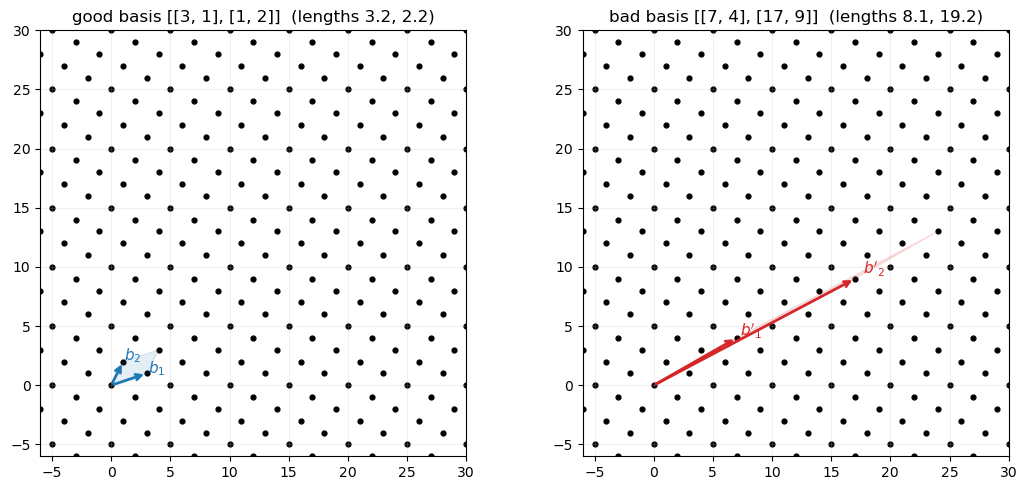

In [77]:
B_good = np.array([[3, 1], [1, 2]])
U = np.array([[2, 1], [5, 2]])
B_bad = U @ B_good
print("B_bad =", B_bad.tolist(), "  det U =", round(np.linalg.det(U)),
      "  |det B_good| =", abs(round(np.linalg.det(B_good))), "  |det B_bad| =", abs(round(np.linalg.det(B_bad))))

plot_bases_2d(B_good, B_bad, xlim=(-6, 30), ylim=(-6, 30))      # plot window; the dots fill all of it

### The same picture in 3-D

A 3-D lattice with the good basis $\mathbf b_1=(2,0,0)$, $\mathbf b_2=(1,2,0)$, $\mathbf b_3=(0,1,2)$, and the bad basis
$\mathbf B'=\mathbf U\mathbf B$ with $\mathbf U=\begin{pmatrix}1&1&0\\1&2&1\\1&2&2\end{pmatrix}$ ($\det\mathbf U=1$).
The points and the cell volume $|\det\mathbf B|=8$ are the same. The good cell is a compact box, while the
bad one is a long, flat parallelepiped. The **green arrow** is a shortest vector, found by the exhaustive search of
Section 0.2. The first figure is static; the second is interactive (drag to rotate, scroll to zoom).
Lattice cryptography works in dimension 500–1000 and more, where no picture helps.

B3_bad = [[3, 2, 0], [4, 5, 2], [4, 6, 4]]   det U3 = 1   |det B3| = 8   |det B3_bad| = 8
a shortest vector: [-2  0  0]  (lambda_1 = 2.000)


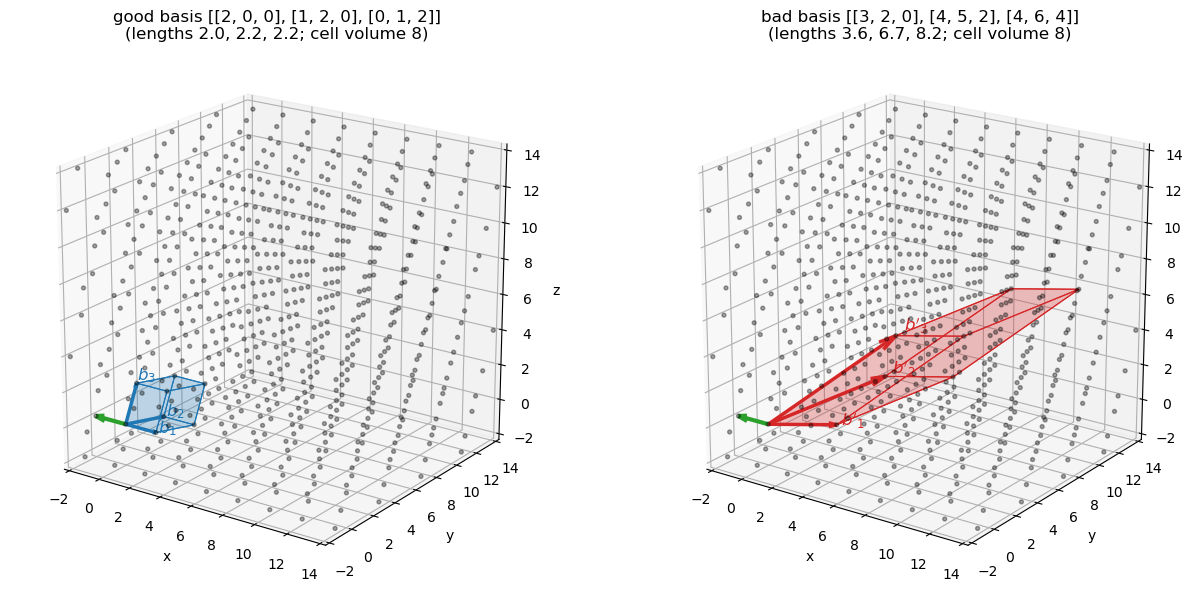

In [78]:
B3 = np.array([[2, 0, 0], [1, 2, 0], [0, 1, 2]])
U3 = np.array([[1, 1, 0], [1, 2, 1], [1, 2, 2]])
B3_bad = U3 @ B3
v_short, c_short, lam3, _ = svp_box(B3, R=2)
print("B3_bad =", B3_bad.tolist(), "  det U3 =", round(np.linalg.det(U3)),
      "  |det B3| =", abs(round(np.linalg.det(B3))), "  |det B3_bad| =", abs(round(np.linalg.det(B3_bad))))
print(f"a shortest vector: {v_short}  (lambda_1 = {lam3:.3f})")

plot_bases_3d(B3, B3_bad, v_short, lo=-2, hi=14)

In [79]:
plot_bases_3d_interactive(B3, B3_bad, v_short, lo=-2, hi=14)    # drag to rotate, scroll to zoom

## <a id="s0-2"></a>0.2 Shortest Vector Problem (SVP)

**SVP:** find $\mathbf v\in\mathcal L\setminus\{0\}$ with $\|\mathbf v\|=\lambda_1$.
The obvious algorithm tries every coefficient vector $\mathbf c\in\{-R,\dots,R\}^n$, which is
$(2R+1)^n$ candidates. It is only correct if $R$ is large enough, and a bad basis forces a large $R$:
the shortest vector here is $5\mathbf b'_1-2\mathbf b'_2$ (huge $-$ huge $=$ tiny), just as on the slide.

In [80]:
for name, B in [("good", B_good), ("bad", B_bad)]:
    for R in (1, 2, 5):
        v, c, length, count = svp_box(B, R)
        print(f"{name:>4} basis, R = {R}: {count:>4} candidates -> shortest found v = {v} = {c[0]:+d} b1 {c[1]:+d} b2,"
              f"  |v| = {length:.3f}")
print(f"\nlambda_1 = sqrt(5) = {np.sqrt(5):.3f}")

good basis, R = 1:    8 candidates -> shortest found v = [-2  1] = -1 b1 +1 b2,  |v| = 2.236
good basis, R = 2:   24 candidates -> shortest found v = [-2  1] = -1 b1 +1 b2,  |v| = 2.236
good basis, R = 5:  120 candidates -> shortest found v = [-2  1] = -1 b1 +1 b2,  |v| = 2.236
 bad basis, R = 1:    8 candidates -> shortest found v = [-7 -4] = -1 b1 +0 b2,  |v| = 8.062
 bad basis, R = 2:   24 candidates -> shortest found v = [3 1] = -2 b1 +1 b2,  |v| = 3.162
 bad basis, R = 5:  120 candidates -> shortest found v = [-1 -2] = -5 b1 +2 b2,  |v| = 2.236

lambda_1 = sqrt(5) = 2.236


### The exponential wall

Now random lattices in dimension $n=2,\dots,9$, searched with $R=2$: that is $5^n$ candidates, so the work
grows $5\times$ per dimension. The measured time grows a little faster, as the arrays outgrow the caches. Extrapolating the measured times shows why dimension alone is
a defense. Better exact algorithms exist, but they are all exponential as well:
enumeration costs $2^{\Theta(n\log n)}$, and sieving $2^{0.292\,n}$ time with $2^{0.2075\,n}$ memory.

n | candidates 5^n | box search (s) | shortest |v| found
--+----------------+----------------+-------------------
2 |             24 |         0.0002 |              3.606
3 |            124 |         0.0002 |              4.690
4 |            624 |         0.0004 |              7.616
5 |          3,124 |         0.0055 |              7.141
6 |         15,624 |         0.0026 |              4.796
7 |         78,124 |         0.0163 |              4.472
8 |        390,624 |         0.0665 |              8.718
9 |      1,953,124 |         0.3970 |             11.000

fit: time grows x3.3 per dimension. Extrapolated box search (R = 2):
   n =   20:  ~10^-2 years
   n =   50:  ~10^13 years
   n =  100:  ~10^39 years
   n = 1024:  ~10^513 years


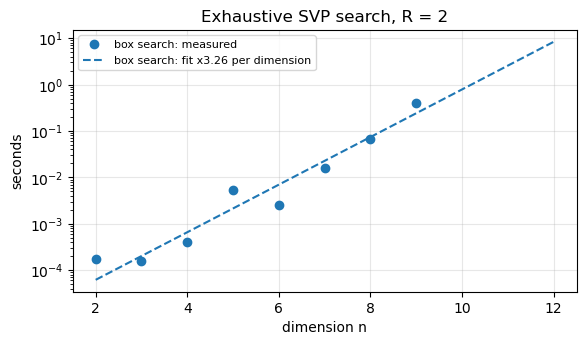

In [81]:
rows, dims, secs = [], [], []
for n in range(2, 10):
    (v, c, length, count), dt = timed(svp_box, random_basis(n), 2)
    rows.append((n, count, dt, length)); dims.append(n); secs.append(dt)
print_table(["n", "candidates 5^n", "box search (s)", "shortest |v| found"], rows, ["", ",", ".4f", ".3f"])

a, b = fit_growth(dims[3:], secs[3:])
print(f"\nfit: time grows x{2**a:.1f} per dimension. Extrapolated box search (R = 2):")
for n in (20, 50, 100, 1024):
    print(f"   n = {n:>4}:  ~10^{log10_years(a * n + b):.0f} years")

plot_growth([("box search", dims, secs, (a, b), "tab:blue")], np.arange(2, 13), "dimension n",
            "Exhaustive SVP search, R = 2")

## <a id="s0-3"></a>0.3 Short Integer Solution (SIS)

**SIS:** given uniform $\mathbf A\in\mathbb Z_q^{n\times m}$, find a nonzero **short** $\mathbf z$ with
$\mathbf A\mathbf z\equiv\mathbf 0\pmod q$, say $\mathbf z\in\{-1,0,1\}^m$.
It is also a hash function, $f_{\mathbf A}(\mathbf x)=\mathbf A\mathbf x \bmod q$ on $\mathbf x\in\{0,1\}^m$:
any collision $f_{\mathbf A}(\mathbf x)=f_{\mathbf A}(\mathbf x')$ gives the SIS solution $\mathbf z=\mathbf x-\mathbf x'$.
Once $2^m>q^n$, the pigeonhole principle guarantees that a collision exists.

Two exponential algorithms:
* **brute force** over all $\mathbf z\in\{-1,0,1\}^m$: $3^m$ candidates;
* **collision search**: hash all $2^m$ binary $\mathbf x$ and look for a repeat: $2^m$ work, and guaranteed to succeed.

In [82]:
q, n, m = 13, 2, 10
A = uniform((n, m), q)
z, tried, nsol = sis_brute_force(A, q)
print(f"toy SIS  n={n}, m={m}, q={q}  (2^m = {2**m} > q^n = {q**n}: a collision must exist)")
print(f"  brute force : {tried:,} candidates, {nsol} solutions; a shortest z = {z},  A z mod q = {(A @ z) % q}")
z, tried = sis_collision(A, q)
print(f"  collision   : {tried:,} hashes;                  z = {z},  A z mod q = {(A @ z) % q}")

toy SIS  n=2, m=10, q=13  (2^m = 1024 > q^n = 169: a collision must exist)
  brute force : 59,049 candidates, 354 solutions; a shortest z = [ 0 -1  0  0  0  0  0  0  0  1],  A z mod q = [0 0]
  collision   : 1,024 hashes;                  z = [1 1 0 1 1 0 1 0 1 0],  A z mod q = [0 0]


## <a id="s0-4"></a>0.4 A higher-dimensional problem, solved by exponential search

SIS in a dimension where pictures are hopeless, solved with a $2^m$ algorithm, and then the exponent itself: how fast do both SIS algorithms slow down as $m$ grows?

**(a) Collision search in dimension $m=20$.** With $q=97$ and $n=3$ we have $2^{20}>97^3$, so hashing all
$2^{20}\approx10^6$ binary vectors must produce a collision. Brute force over $\{-1,0,1\}^{20}$ would need
$3^{20}\approx3.5\times10^9$ tries.

In [83]:
q, n, m = 97, 3, 20
A = uniform((n, m), q)
(z, tried), dt = timed(sis_collision, A, q)
print(f"SIS n={n}, m={m}, q={q}: hashed {tried:,} vectors in {dt:.2f}s")
print(f"  z = {z}")
print(f"  A z mod q = {(A @ z) % q},  ||z||_inf = {np.abs(z).max()},  ||z||_2 = {np.linalg.norm(z):.2f}")
print(f"  brute force over {{-1,0,1}}^{m} would try {3**m:,} candidates")

SIS n=3, m=20, q=97: hashed 1,048,576 vectors in 0.20s
  z = [0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0]
  A z mod q = [0 0 0],  ||z||_inf = 1,  ||z||_2 = 2.24
  brute force over {-1,0,1}^20 would try 3,486,784,401 candidates


**(b) Fitting the exponent.** Time both SIS algorithms as the dimension $m$ grows, and fit
$\text{time}\approx c\cdot\beta^m$. Brute force should show $\beta\approx3$ (it tries $3^m$ vectors) and the collision
search $\beta\approx2$ (it hashes $2^m$ vectors). The measured $\beta$ comes out a little higher, because each
candidate costs about $m$ operations and the collision search also sorts its hashes. Both are the exponential wall
again, now for SIS. Extrapolating the fits to cryptographic dimensions shows why nobody runs these attacks.

  algorithm | growth per dimension | m = 64 | m = 128 | m = 256 | m = 1024
------------+----------------------+--------+---------+---------+---------
brute force |     x2.08 (ideal x3) | 10^8 y | 10^28 y | 10^69 y | 10^313 y
  collision |     x1.79 (ideal x2) | 10^3 y | 10^19 y | 10^51 y | 10^245 y


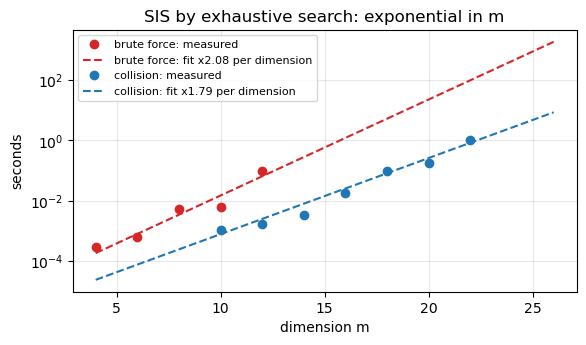

In [84]:
q_t, n_t = 13, 2                                 # small q^n: collisions exist for every m below
bf = [(m, timed(sis_brute_force, uniform((n_t, m), q_t), q_t)[1]) for m in range(4, 13, 2)]    # 3^m candidates
col = [(m, timed(sis_collision, uniform((n_t, m), q_t), q_t)[1]) for m in range(10, 23, 2)]    # 2^m hashes

rows, series = [], []
for name, data, color, ideal in [("brute force", bf, "tab:red", 3), ("collision", col, "tab:blue", 2)]:
    ms, ts = np.array(data).T
    a, b = fit_growth(ms[-3:], ts[-3:])                          # fit on the largest m
    rows.append((name, f"x{2**a:.2f} (ideal x{ideal})", *[f"10^{log10_years(a * m_ + b):.0f} y" for m_ in (64, 128, 256, 1024)]))
    series.append((name, ms, ts, (a, b), color))
print_table(["algorithm", "growth per dimension", "m = 64", "m = 128", "m = 256", "m = 1024"], rows)
plot_growth(series, np.arange(4, 27), "dimension m", "SIS by exhaustive search: exponential in m")

---
# <a id="s1"></a>1. LWE and Ring-LWE

<small>[&uarr; back to contents](#contents)</small>

In [85]:
# ---- Section 1 helpers.  Parameters: HE-standard 128-bit point (ternary secret), sigma as in OpenFHE.
n, q, sigma = 1024, 2**27, 3.19
N = n                                       # ring dimension for Ring-LWE (1.4)
Delta = q // 2                              # floor(q/2) rounded; q is even here

# LWE / Regev (slide 28):  c = (a, b),  b = <a, s> + e + m*Delta
def enc(m, s):
    a = uniform(n, q)
    e = int(gaussian((), sigma))
    return a, (a @ s + e + m * Delta) % q

def value(c, s):                            # v = b - <a, s> mod q, centered into (-q/2, q/2]
    a, b = c
    return int(centered(b - a @ s, q))

def bit(v):                                 # the decryption rule: |v| >= q/4 -> 1
    return int(abs(v) >= q // 4)

def noise(v, m):                            # what is left after removing m*Delta
    return int(centered(v - m * Delta, q))

def add(c1, c2):
    return (c1[0] + c2[0]) % q, (c1[1] + c2[1]) % q

def as_vector(c):                           # (a, b) -> c = (b, -a), centered
    a, b = c
    return centered(np.concatenate(([b], -a)), q)

def mult(c1, c2):
    t = np.outer(as_vector(c1), as_vector(c2)).ravel()        # c1 (x) c2, |t| <= q^2/4
    return np.mod(np.floor_divide(t + q // 4, q // 2), q)     # round(2 t / q) mod q

def tensor_value(ct, s):                    # <c_x, s~ (x) s~> mod q, with s~ = (1, s)
    s_t = np.concatenate(([1], s))
    return int(centered(ct @ np.outer(s_t, s_t).ravel(), q))

# Ring-LWE in R_q = Z_q[X]/(X^N + 1):  ct = (c0, c1) with c0 + c1*s = Delta*m + e
def polymul(x, y):
    # Exact product in Z[X]/(X^N+1): O(N^2) here; the NTT (Section 2) makes it O(N log N).
    full = np.convolve(x, y)                # int64 is enough for centered inputs at these sizes
    res = full[:N].copy()
    res[:N - 1] -= full[N:]                 # X^N = -1 : fold the top half back with a sign flip
    return res

def rot_matrix(a):                          # columns a, X a, X^2 a, ... (negacyclic shifts)
    M = np.empty((len(a), len(a)), dtype=np.int64)
    col = a.copy()
    for j in range(len(a)):
        M[:, j] = col
        col = np.concatenate(([-col[-1]], col[:-1]))
    return M

def r_enc(msg, s):
    a = uniform(N, q)
    e = gaussian(N)
    return np.mod(polymul(centered(a, q), s) + e + Delta * msg, q), np.mod(-a, q)

def r_value(ct, s):                         # v = c0 + c1*s mod q, one value per coefficient
    return centered(ct[0] + polymul(centered(ct[1], q), s), q)

def r_value3(d, s):                         # v = d0 + d1*s + d2*s^2 mod q, for a 3-component product
    return centered(d[0] + polymul(centered(d[1], q), s) + polymul(centered(d[2], q), polymul(s, s)), q)

def r_add(x, y):
    return np.mod(x[0] + y[0], q), np.mod(x[1] + y[1], q)

def r_mult(x, y):
    x0, x1, y0, y1 = (centered(t, q) for t in (*x, *y))
    rnd = lambda t: np.mod(np.floor_divide(t + q // 4, q // 2), q)   # round(2 t / q) mod q
    return rnd(polymul(x0, y0)), rnd(polymul(x0, y1) + polymul(x1, y0)), rnd(polymul(x1, y1))

def bits_of(v):                             # the decryption rule, coefficient by coefficient
    return (np.abs(v) >= q // 4).astype(np.int64)

def bitpoly_str(v):
    return " + ".join("1" if i == 0 else "X" if i == 1 else f"X^{i}" for i in np.flatnonzero(v)) or "0"

# ---- printing and plotting
def explain_decryption(label, what, v, expected):
    # How v decides the bit, the noise that is left, and the budget log2((q/4)/|e|).
    cmp = ">=" if bit(v) else "< "
    e_ = noise(v, expected)
    print(f"\n{label}:")
    print(f"   {what} mod q = {v:,}   (centered into (-q/2, q/2])")
    print(f"   |{what}| {cmp} q/4 :  {abs(v):,} {cmp} {q // 4:,}   ->  m = {bit(v)}   (expected {expected})")
    print(f"   noise e = v - m*Delta = {e_}   ->  budget = log2((q/4)/|e|) = log2({q // 4:,}/{max(1, abs(e_))})"
          f" = {budget_bits(e_, q):.1f} bits")

def plot_lwe_histograms(b, u, e_found, m):
    # Left/middle: LWE vector vs. truly random vector (32 bins over [0, q)); right: the errors, given s.
    bins = np.linspace(0, q, 33)
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))
    ax[0].hist(b, bins=bins, color="tab:blue"); ax[0].set_title("LWE:  b = A s + e  mod q")
    ax[1].hist(u, bins=bins, color="tab:gray"); ax[1].set_title("truly random:  u uniform in [0, q)")
    for a_ in ax[:2]:
        a_.set_xlabel("value of one entry  (0 <= value < q = 2^27)")
        a_.set_ylabel(f"number of entries (of m = {m})")
        a_.set_ylim(0, 1.6 * m / 32)
    ax[2].hist(e_found, bins=np.arange(-15.5, 16.5), color="tab:orange")
    ax[2].set_title("with the secret:  b - A s  mod q = e")
    ax[2].set_xlabel("value of one error entry e_i (centered)")
    ax[2].set_ylabel(f"number of entries (of m = {m})")
    plt.tight_layout(); plt.show()

def plot_decryption_values(items, title):
    # Draw v = b - <a,s> (centered) for each ciphertext on the Z_q line, as in the slide's picture.
    fig, ax = plt.subplots(figsize=(10, 1.8))
    ax.axhline(0, color="k", lw=0.8)
    for x, lab in [(-q/2, "-q/2"), (0, "0 (m=0)"), (q/2, "q/2 (m=1)")]:
        ax.plot([x, x], [-0.05, 0.05], "k"); ax.text(x, -0.25, lab, ha="center", fontsize=8)
    for x, lab in [(-q/4, "-q/4"), (q/4, "q/4")]:
        ax.axvline(x, color="red", ls="--", lw=0.8); ax.text(x, 0.3, lab, color="red", ha="center", fontsize=8)
    for i, (v, lab) in enumerate(items):
        ax.plot(v, 0, "o", ms=8)
        ax.annotate(lab, (v, 0), xytext=(0, 12 + 12 * (i % 2)), textcoords="offset points", ha="center", fontsize=8)
    ax.set_xlim(-0.56 * q, 0.56 * q); ax.set_ylim(-0.4, 0.5); ax.axis("off"); ax.set_title(title, fontsize=10)
    plt.show()

## <a id="s1-1"></a>1.1 What an LWE instance looks like

Fix a modulus $q$, a dimension $n$, a secret $\mathbf s$, and a narrow error distribution $\chi$.
An **LWE sample** is

$$
(\mathbf a,\ b) \;=\; \big(\mathbf a,\ \langle \mathbf a, \mathbf s\rangle + e \bmod q\big),
\qquad \mathbf a \xleftarrow{\$} \mathbb Z_q^n,\quad e \leftarrow \chi .
$$

Stacking $m$ samples gives a matrix $\mathbf A\in\mathbb Z_q^{m\times n}$ and
$\mathbf b = \mathbf A\mathbf s + \mathbf e \bmod q$.

* **Search-LWE:** given $(\mathbf A,\mathbf b)$, recover $\mathbf s$.
* **Decision-LWE:** tell $(\mathbf A,\mathbf b)$ apart from a uniformly random pair.

Without $\mathbf e$ this is just Gaussian elimination. With the small error, both problems are believed hard,
even for quantum computers. First, a toy instance small enough to read:

In [86]:
rng = np.random.default_rng(2026)          # reseed: Section 1 does not depend on Section 0
n_toy, q_toy, m_toy = 8, 97, 4             # toy sizes
A = uniform((m_toy, n_toy), q_toy)
s = uniform(n_toy, q_toy)
e = gaussian(m_toy, sigma=1.0)
b = (A @ s + e) % q_toy

print("A =\n", A)
print("s =", s)
print("e =", e)
print("b = A s + e mod q =", b)
print("    A s     mod q =", (A @ s) % q_toy, "  <- b is off by the small error e")

A =
 [[82 17  2 62 35 45  7 35]
 [62 34 80 76 68 87 69 17]
 [83 63  9 28 16 93 70 89]
 [27 61 58 73 11 49 62 80]]
s = [63 43 44 32 15 26 14 21]
e = [0 1 0 0]
b = A s + e mod q = [21 18 90  7]
    A s     mod q = [21 17 90  7]   <- b is off by the small error e


### Real parameter sizes

| Where it is used | Problem | Dimension | Modulus | Secret / error |
|---|---|---|---|---|
| ML-KEM-768 (NIST FIPS 203) | module-LWE | $3\times256 = 768$ | $q=3329$ (12 bits) | centered binomial, $\eta=2$ |
| OpenFHE FHEW/TFHE `STD128` | LWE | $n=503$ | $q=1024$ (10 bits) | ternary $\mathbf s$, $\sigma=3.19$ |
| &nbsp;&nbsp;… its bootstrapping keys | RLWE | $N=1024$ | $Q\approx2^{27}$ | ternary $\mathbf s$, $\sigma=3.19$ |
| HE standard, 128-bit, ternary secret | (R)LWE | $1024 \;\dots\; 65536$ | $\log_2 Q \le 27 \;\dots\; 1747$ | ternary $\mathbf s$, $\sigma=3.19$ |

*Sources:* FIPS 203; OpenFHE `src/binfhe/lib/binfhecontext.cpp` and `src/core/lib/lattice/stdlatticeparms.cpp`.

The rest of this section uses the **HE-standard 128-bit point**: $n=1024$, $q=2^{27}$, ternary
$\mathbf s\in\{-1,0,1\}^n$, $\sigma=3.19$.
The slides write $\mathbf s\in\mathbb Z_q^n$. FHE libraries (including OpenFHE by default) sample a
**ternary** secret instead, and homomorphic multiplication (Section 1.3) needs $\mathbf s$ to be small.

[[ 62521074  60089532 132969653 ... 101135434  14604357  22349584]
 [ 34937868  72493788 105287994 ...  75415464 113372809  10417533]
 [113159231 124077978  18413149 ... 103636119  87093323  17594798]
 ...
 [ 90929629  62620179  85019053 ...  39636923 100388104  25560325]
 [127788706  78605938 106844304 ...   1857610  28702352 121323544]
 [ 61971471  10999371  15902216 ...  65668941  70043568  24271989]]
A: (1024, 1024), entries up to 134,217,279 (< q = 2^27)
s: [ 1 -1  1 -1 -1 -1  1  0  1 -1 -1 -1] ...   (ternary)
e: [-6  0 -3 -5 -1 -1  1  0 -2  2  2  3] ...   (|e| <= 11)
b: [  3388697  10506893 125777935  86885807 120870555 114604649] ...
as a Regev ciphertext, one sample (a, b) carries 1 plaintext bit:
   OpenFHE FHEW STD128: (n+1) log2 q = 5,040 bits = 630 B for 1 plaintext bit  ->  5,040x growth
    HE standard n=1024: (n+1) log2 q = 27,675 bits = 3.4 KiB for 1 plaintext bit  ->  27,675x growth
chi-square test against uniform,     LWE vector b: p-value = 0.91
chi-square test again

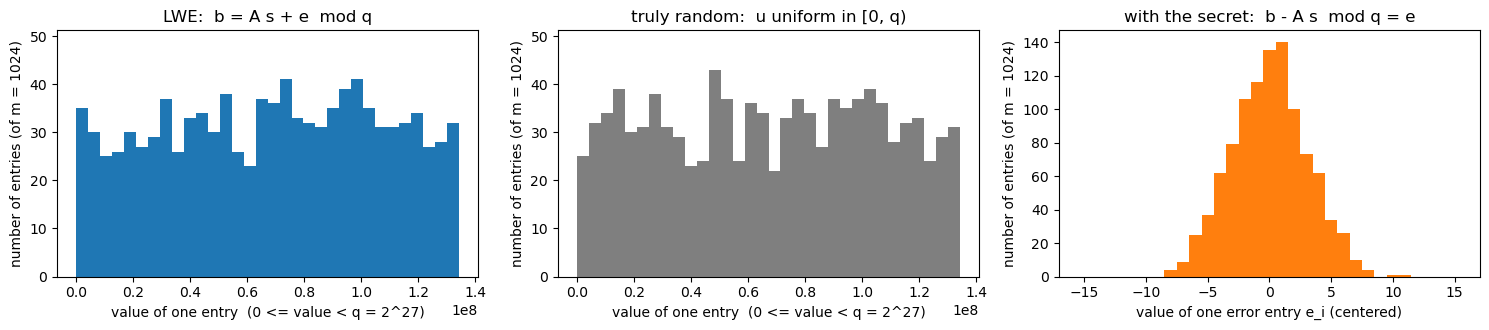

In [87]:
m = 1024                                    # number of samples; n = 1024, q = 2^27 from the helper cell
A = uniform((m, n), q)
s = ternary(n)
e = gaussian(m)
b = (A @ s + e) % q

print(A)
print(f"A: {A.shape}, entries up to {A.max():,} (< q = 2^27)")
print(f"s: {s[:12]} ...   (ternary)")
print(f"e: {e[:12]} ...   (|e| <= {np.abs(e).max()})")
print(f"b: {b[:6]} ...")
print("as a Regev ciphertext, one sample (a, b) carries 1 plaintext bit:")
for name, n_, q_ in [("OpenFHE FHEW STD128", 503, 2**10), ("HE standard n=1024", 1024, 2**27)]:
    bits = (n_ + 1) * np.log2(q_)
    print(f"{name:>22}: (n+1) log2 q = {bits:,.0f} bits = {human_bytes(bits / 8)} for 1 plaintext bit"
          f"  ->  {expansion(bits, 1)} growth")

# Decision-LWE in one picture: is b distinguishable from a truly random vector u?
from scipy.stats import chisquare
u = uniform(m, q)                           # m truly uniform numbers in [0, q), for comparison
for name, v in [("LWE vector b", b), ("uniform vector u", u)]:
    counts, _ = np.histogram(v, bins=np.linspace(0, q, 33))
    print(f"chi-square test against uniform, {name:>16}: p-value = {chisquare(counts).pvalue:.2f}")
print("(p-values are spread over [0, 1] for uniform data, so neither vector looks suspicious)")
plot_lwe_histograms(b, u, centered(b - A @ s, q), m)

**Reading the figure.** Each panel is a histogram of the $m=1024$ entries of one vector. The $x$-axis is the
value of an entry, and the $y$-axis counts how many entries fall in each bin (32 equal bins over $[0,q)$ in the
first two panels). Without the secret, the LWE vector $\mathbf b$ (left) looks just like a truly random vector
(middle). That indistinguishability is **decision-LWE**. With $\mathbf s$, subtracting $\mathbf A\mathbf s$
exposes the tiny errors (right): a Gaussian of width $\sigma\approx3$, compared with $q\approx1.3\times10^8$.

## <a id="s1-2"></a>1.2 Private-key encryption from LWE (Regev)  — *slide 28*

The message bit $m\in\{0,1\}$ goes into the **most significant bit** by scaling it with
$\Delta=\lfloor q/2\rceil$:

$$
\textbf{Enc}_{\mathbf s}(m):\quad \mathbf a\xleftarrow{\$}\mathbb Z_q^n,\ e\leftarrow\chi;\qquad
c=(\mathbf a,\ b),\quad b=\langle\mathbf a,\mathbf s\rangle+e+m\,\Delta .
$$

$$
\textbf{Dec}_{\mathbf s}(c):\quad v=b-\langle\mathbf a,\mathbf s\rangle \bmod q
= \underbrace{e}_{\text{noise}}+m\,\Delta;\qquad
\hat m = \begin{cases}0 & |v|<q/4\\ 1 & \text{otherwise.}\end{cases}
$$

A ciphertext is an LWE sample with $m\Delta$ added to it, so it is secure if decision-LWE is hard.
Decryption is correct as long as $|e|<q/4$: then $v=b-\langle\mathbf a,\mathbf s\rangle$ stays within $q/4$ of $0$
(for $m=0$) or of $\pm q/2$ (for $m=1$; after centering, $+q/2$ and $-q/2$ are the same point mod $q$).
The printouts below write $v$ out as `b - <a,s>`.

**Noise budget.** How much room is left before decryption breaks is measured in bits,

$$
\text{budget}=\log_2\frac{q/4}{|e|}\ \text{bits},
$$

which counts how many more times the noise could **double** before $|e|$ reaches $q/4$. Here $q/4=2^{25}$, so a
fresh ciphertext with $|e|=3$ has $\log_2(2^{25}/3)\approx23.4$ bits left. Every homomorphic operation spends some of
this budget, and at $0$ bits decryption fails.

In [88]:
s = ternary(n)                              # the secret key
m1, m2 = 1, 0                               # the two bits we encrypt
c1, c2 = enc(m1, s), enc(m2, s)
for name, (a, b), msg in [("c1", c1, m1), ("c2", c2, m2)]:
    print(f"{name} = Enc({msg}):  a = [{a[0]}, {a[1]}, {a[2]}, ..., {a[-1]}]  (n = {len(a)}),  b = {b}")

print(f"\nq = {q:,},  q/4 = {q // 4:,},  Delta = q/2 = {Delta:,}")
print("rule: |b - <a,s>| < q/4 -> m = 0 (value near 0);  otherwise m = 1 (value near +-q/2)")
explain_decryption("Dec(c1)", "b - <a,s>", value(c1, s), m1)
explain_decryption("Dec(c2)", "b - <a,s>", value(c2, s), m2)

c1 = Enc(1):  a = [58855641, 76373128, 77298567, ..., 119848867]  (n = 1024),  b = 61525802
c2 = Enc(0):  a = [98796655, 54904105, 66649245, ..., 68909984]  (n = 1024),  b = 81177769

q = 134,217,728,  q/4 = 33,554,432,  Delta = q/2 = 67,108,864
rule: |b - <a,s>| < q/4 -> m = 0 (value near 0);  otherwise m = 1 (value near +-q/2)

Dec(c1):
   b - <a,s> mod q = -67,108,862   (centered into (-q/2, q/2])
   |b - <a,s>| >= q/4 :  67,108,862 >= 33,554,432   ->  m = 1   (expected 1)
   noise e = v - m*Delta = 2   ->  budget = log2((q/4)/|e|) = log2(33,554,432/2) = 24.0 bits

Dec(c2):
   b - <a,s> mod q = 1   (centered into (-q/2, q/2])
   |b - <a,s>| <  q/4 :  1 <  33,554,432   ->  m = 0   (expected 0)
   noise e = v - m*Delta = 1   ->  budget = log2((q/4)/|e|) = log2(33,554,432/1) = 25.0 bits


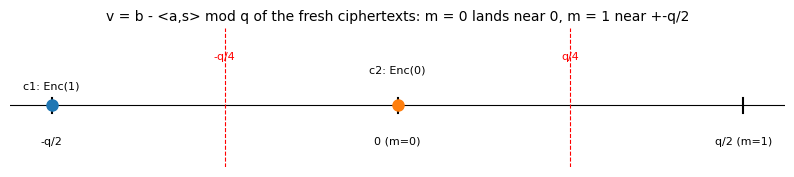

In [89]:
plot_decryption_values([(value(c1, s), f"c1: Enc({m1})"), (value(c2, s), f"c2: Enc({m2})")],
                       "v = b - <a,s> mod q of the fresh ciphertexts: m = 0 lands near 0, m = 1 near +-q/2")

## <a id="s1-3"></a>1.3 Computing on the ciphertexts: add and multiply

**Addition** works component by component: $c_1+c_2=(\mathbf a_1+\mathbf a_2,\ b_1+b_2)$.
Decrypting it gives $b-\langle\mathbf a,\mathbf s\rangle=(m_1+m_2)\Delta+(e_1+e_2)$. Because $2\Delta=q\equiv0$, it decrypts to
$m_1\oplus m_2$ (**XOR**), and the noises simply add.

**Multiplication.** Write a ciphertext as the vector $\mathbf c=(b,\,-\mathbf a)\in\mathbb Z_q^{n+1}$ and the key as
$\tilde{\mathbf s}=(1,\mathbf s)$. Then decryption is linear: $\langle\mathbf c,\tilde{\mathbf s}\rangle = m\Delta+e$.
The product of the two decryption values is a linear function of the **tensor product**:

$$
\langle\mathbf c_1,\tilde{\mathbf s}\rangle\cdot\langle\mathbf c_2,\tilde{\mathbf s}\rangle
=\big\langle \mathbf c_1\otimes\mathbf c_2,\ \tilde{\mathbf s}\otimes\tilde{\mathbf s}\big\rangle .
$$

Scaling by $2/q$ and rounding (Brakerski's scale-invariant trick, the core of BFV) gives

$$
\mathbf c_\times=\Big\lfloor \tfrac{2}{q}\,(\mathbf c_1\otimes\mathbf c_2)\Big\rceil \bmod q,
\qquad
\langle\mathbf c_\times,\ \tilde{\mathbf s}\otimes\tilde{\mathbf s}\rangle \approx m_1m_2\,\Delta+\text{noise},
$$

which decrypts to $m_1 m_2$ (**AND**). Two costs appear right away:

* the ciphertext grows from $n+1$ to $(n+1)^2$ numbers (for the same 1-bit plaintext: from $27{,}675\times$ to
  $\approx28$ million$\times$ its size) and now decrypts under $\tilde{\mathbf s}\otimes\tilde{\mathbf s}$.
  **Relinearization** (a key switch) shrinks it back. It is the expensive step in the CKKS section.
* the noise grows much faster than under addition: it picks up terms like $2\,e_1k_2$, where $q\,k_2$ is the
  multiple of $q$ hidden in $\langle\mathbf c_2,\tilde{\mathbf s}\rangle$. That is why $\mathbf s$ must be small.

In [90]:
c_add, c_mul = add(c1, c2), mult(c1, c2)
bits_per_number = np.log2(q)                # 27 bits per number mod q = 2^27
size_add, size_mul = (len(c_add[0]) + 1) * bits_per_number, c_mul.size * bits_per_number
print(f"c1 + c2: {len(c_add[0]) + 1:,} numbers = {human_bytes(size_add / 8)} for 1 plaintext bit  ->  {expansion(size_add, 1)} growth;  key (1, s)")
explain_decryption("Dec(c1 + c2)", "b - <a,s>", value(c_add, s), m1 ^ m2)
print(f"\nc1 x c2: {c_mul.size:,} numbers = {human_bytes(size_mul / 8)} for 1 plaintext bit  ->  {expansion(size_mul, 1)} growth;  key s~ (x) s~")
explain_decryption("Dec(c1 x c2)", "<c_x, s~(x)s~>", tensor_value(c_mul, s), m1 & m2)

c1 + c2: 1,025 numbers = 3.4 KiB for 1 plaintext bit  ->  27,675x growth;  key (1, s)

Dec(c1 + c2):
   b - <a,s> mod q = -67,108,861   (centered into (-q/2, q/2])
   |b - <a,s>| >= q/4 :  67,108,861 >= 33,554,432   ->  m = 1   (expected 1)
   noise e = v - m*Delta = 3   ->  budget = log2((q/4)/|e|) = log2(33,554,432/3) = 23.4 bits

c1 x c2: 1,050,625 numbers = 3.4 MiB for 1 plaintext bit  ->  28,366,875x growth;  key s~ (x) s~

Dec(c1 x c2):
   <c_x, s~(x)s~> mod q = 259   (centered into (-q/2, q/2])
   |<c_x, s~(x)s~>| <  q/4 :  259 <  33,554,432   ->  m = 0   (expected 0)
   noise e = v - m*Delta = 259   ->  budget = log2((q/4)/|e|) = log2(33,554,432/259) = 17.0 bits


Now all four input pairs. For each ciphertext the table shows the decrypted value $v$
(`b - <a,s>` for fresh and added ciphertexts, $\langle\mathbf c_\times,\tilde{\mathbf s}\otimes\tilde{\mathbf s}\rangle$
for the product), how it compares with $q/4$, the resulting bit, the noise $e=v-m\Delta$, and the remaining
**budget** $\log_2\frac{q/4}{|e|}$. Compare the budget columns: addition costs about one bit at most, while a
multiplication costs several.

In [91]:
rows = []
for m1_, m2_ in [(0, 0), (0, 1), (1, 0), (1, 1)]:
    a1, a2 = enc(m1_, s), enc(m2_, s)
    for name, what, v, expect in [("fresh c1", "b - <a,s>", value(a1, s), m1_),
                                  ("c1 + c2", "b - <a,s>", value(add(a1, a2), s), m1_ ^ m2_),
                                  ("c1 x c2", "<c_x, s~(x)s~>", tensor_value(mult(a1, a2), s), m1_ & m2_)]:
        e_ = noise(v, expect)
        rows.append((f"{m1_}  {m2_}" if name == "fresh c1" else "", name, what, v, ">=" if bit(v) else "<", bit(v),
                     f"{expect} {'ok' if bit(v) == expect else 'FAIL'}", e_, f"{budget_bits(e_, q):.1f} bits"))
print(f"q/4 = {q // 4:,};  budget = log2((q/4) / |noise|)\n")
print_table(["m1 m2", "ciphertext", "decrypted value", "v", "vs q/4", "-> m", "expected", "noise", "budget"],
            rows, ["", "", "", ",", "", "", "", "", ""])

q/4 = 33,554,432;  budget = log2((q/4) / |noise|)

m1 m2 | ciphertext | decrypted value |           v | vs q/4 | -> m | expected | noise |    budget
------+------------+-----------------+-------------+--------+------+----------+-------+----------
 0  0 |   fresh c1 |       b - <a,s> |          -3 |      < |    0 |     0 ok |    -3 | 23.4 bits
      |    c1 + c2 |       b - <a,s> |          -3 |      < |    0 |     0 ok |    -3 | 23.4 bits
      |    c1 x c2 |  <c_x, s~(x)s~> |          88 |      < |    0 |     0 ok |    88 | 18.5 bits
 0  1 |   fresh c1 |       b - <a,s> |          -3 |      < |    0 |     0 ok |    -3 | 23.4 bits
      |    c1 + c2 |       b - <a,s> |  67,108,862 |     >= |    1 |     1 ok |    -2 | 24.0 bits
      |    c1 x c2 |  <c_x, s~(x)s~> |          54 |      < |    0 |     0 ok |    54 | 19.2 bits
 1  0 |   fresh c1 |       b - <a,s> |  67,108,864 |     >= |    1 |     1 ok |     0 | 25.0 bits
      |    c1 + c2 |       b - <a,s> |  67,108,857 |     >= |    1 

**Takeaways.** Addition barely touches the noise budget, while a single multiplication uses several bits of it.
Chaining multiplications eventually pushes the noise past $q/4$, which is the reason for **bootstrapping**.
Plain LWE is also wasteful: each plaintext bit becomes $(n+1)\log_2 q\approx 27{,}700$ bits of ciphertext
(a $27{,}675\times$ growth), and a product becomes a million numbers ($\approx28$ million$\times$ the 1-bit plaintext). Ring-LWE fixes the size problem.

## <a id="s1-4"></a>1.4 Ring-LWE: one sample carries $N$ LWE samples

Replace vectors by polynomials in $\mathcal R_q=\mathbb Z_q[X]/(X^N+1)$:

$$
(a,\ b)=(a,\ a\cdot s+e)\in\mathcal R_q^2,\qquad a\xleftarrow{\$}\mathcal R_q,\quad s\ \text{ternary},\quad e\leftarrow\chi^N .
$$

The product $a\cdot s$ is a **negacyclic convolution** ($X^N=-1$). It equals $\mathrm{Rot}(a)\,\mathbf s$, where
$\mathrm{Rot}(a)$ is the $N\times N$ matrix whose $j$-th column is $X^j a$. So one RLWE sample *is* an
LWE instance with $N$ samples, whose matrix is described by only $N$ numbers instead of $N^2$.

In [92]:
a = uniform(N, q)
s_r = ternary(N)
e_r = gaussian(N)
b_r = np.mod(polymul(centered(a, q), s_r) + e_r, q)

same = np.array_equal(np.mod(rot_matrix(centered(a, q)) @ s_r, q), np.mod(polymul(centered(a, q), s_r), q))
print("a . s (ring product)  ==  Rot(a) @ s (LWE matrix product):", same)

lwe_bits  = (N * N + N) * np.log2(q)         # N LWE samples: A (N x N) and b
rlwe_bits = 2 * N * np.log2(q)               # one RLWE sample: a and b
print(f"both encrypt N = {N} plaintext bits = {human_bytes(N / 8)}:")
print(f"   N LWE samples : {human_bytes(lwe_bits / 8):>10}  ->  {expansion(lwe_bits, N)} growth")
print(f"   1 RLWE sample : {human_bytes(rlwe_bits / 8):>10}  ->  {expansion(rlwe_bits, N)} growth"
      f"   ({lwe_bits / rlwe_bits:.0f}x smaller than LWE)")

a . s (ring product)  ==  Rot(a) @ s (LWE matrix product): True
both encrypt N = 1024 plaintext bits = 128 B:
   N LWE samples :    3.4 MiB  ->  27,675x growth
   1 RLWE sample :    6.8 KiB  ->  54x growth   (512x smaller than LWE)


### RLWE encryption: $N$ bits at once, and the 3-component product

Encrypt a whole bit-polynomial $m\in\{0,1\}^N$ in the form the CKKS slides use,
$\mathrm{ct}=(c_0,c_1)$ with $c_0+c_1 s = \Delta m + e$:

$$
c_0 = a\cdot s + e + \Delta m,\qquad c_1=-a .
$$

* **Add:** $(c_0+c_0',\ c_1+c_1')$ decrypts to $m\oplus m'$, coefficient by coefficient.
* **Multiply:** multiplying the two linear forms gives a **3-term** ciphertext under $(1,s,s^2)$:
  $$
  (d_0,d_1,d_2)=\Big\lfloor\tfrac{2}{q}\big(c_0c_0',\ c_0c_1'+c_1c_0',\ c_1c_1'\big)\Big\rceil,\qquad
  d_0+d_1s+d_2s^2\approx\Delta\,(m\cdot m')+\text{noise}.
  $$
  Note that $m\cdot m'$ is a **polynomial product** in $\mathbb Z_2[X]/(X^N+1)$, not a bitwise AND.
  Getting slot-wise (SIMD) products needs an encoding, which is exactly what CKKS encoding does.

In [93]:
# Two readable bit-polynomials: m = 1 + X^3 and m' = X + X^5 + X^1023
msg1 = np.zeros(N, dtype=np.int64); msg1[[0, 3]] = 1
msg2 = np.zeros(N, dtype=np.int64); msg2[[1, 5, 1023]] = 1
ct1, ct2 = r_enc(msg1, s_r), r_enc(msg2, s_r)

v1 = r_value(ct1, s_r)
print("Dec(ct1), coefficient by coefficient: v = c0 + c1*s mod q, then |v_i| >= q/4 -> bit 1")
for i in range(6):
    print(f"   i = {i}:  v_i = {v1[i]:>13,}   |v_i| {'>=' if abs(v1[i]) >= q // 4 else '< '} q/4 = {q // 4:,}"
          f"  ->  {int(abs(v1[i]) >= q // 4)}")
print("   ... (all 1024 coefficients the same way)\n")
print("Dec(ct1)       =", bitpoly_str(bits_of(v1)))
print("Dec(ct2)       =", bitpoly_str(bits_of(r_value(ct2, s_r))))
print("Dec(ct1 + ct2) =", bitpoly_str(bits_of(r_value(r_add(ct1, ct2), s_r))))
print("Dec(ct1 x ct2) =", bitpoly_str(bits_of(r_value3(r_mult(ct1, ct2), s_r))),
      "  <- (1 + X^3)(X + X^5 + X^1023) mod (X^1024 + 1, 2)")

Dec(ct1), coefficient by coefficient: v = c0 + c1*s mod q, then |v_i| >= q/4 -> bit 1
   i = 0:  v_i =   -67,108,859   |v_i| >= q/4 = 33,554,432  ->  1
   i = 1:  v_i =            -1   |v_i| <  q/4 = 33,554,432  ->  0
   i = 2:  v_i =            -2   |v_i| <  q/4 = 33,554,432  ->  0
   i = 3:  v_i =    67,108,862   |v_i| >= q/4 = 33,554,432  ->  1
   i = 4:  v_i =            -3   |v_i| <  q/4 = 33,554,432  ->  0
   i = 5:  v_i =            -1   |v_i| <  q/4 = 33,554,432  ->  0
   ... (all 1024 coefficients the same way)

Dec(ct1)       = 1 + X^3
Dec(ct2)       = X + X^5 + X^1023
Dec(ct1 + ct2) = 1 + X + X^3 + X^5 + X^1023
Dec(ct1 x ct2) = X + X^2 + X^4 + X^5 + X^8 + X^1023   <- (1 + X^3)(X + X^5 + X^1023) mod (X^1024 + 1, 2)


In [94]:
# Full random N-bit messages: check every coefficient, and track the noise
msg1, msg2 = rng.integers(0, 2, N), rng.integers(0, 2, N)
ct1, ct2 = r_enc(msg1, s_r), r_enc(msg2, s_r)
cases = [("fresh ct1", r_value(ct1, s_r), msg1),
         ("ct1 + ct2", r_value(r_add(ct1, ct2), s_r), msg1 ^ msg2),
         ("ct1 x ct2", r_value3(r_mult(ct1, ct2), s_r), np.mod(polymul(msg1, msg2), 2))]
rows = []
for name, v, want in cases:
    nz = centered(v - Delta * want, q)
    rows.append((name, str(np.array_equal(bits_of(v), want)), int(np.abs(nz).max()), budget_bits(nz, q)))
print("noise_i = v_i - Delta*m_i for every coefficient i;  budget = log2((q/4) / max_i |noise_i|)  (the worst coefficient)\n")
print_table(["", f"all {N} coefficients correct", "max |noise|", "budget bits"], rows, ["", "", ",", ".1f"])
print(f"\nRLWE ciphertext: 2 x {N} x 27 bits = {human_bytes(2 * N * 27 / 8)} for {N} plaintext bits ({human_bytes(N / 8)})"
      f"  ->  {expansion(2 * N * 27, N)} growth")
print(f"LWE ciphertext : {human_bytes((1024 + 1) * 27 / 8)} for 1 plaintext bit  ->  {expansion((1024 + 1) * 27, 1)} growth")

noise_i = v_i - Delta*m_i for every coefficient i;  budget = log2((q/4) / max_i |noise_i|)  (the worst coefficient)

          | all 1024 coefficients correct | max |noise| | budget bits
----------+-------------------------------+-------------+------------
fresh ct1 |                          True |          10 |        21.7
ct1 + ct2 |                          True |          16 |        21.0
ct1 x ct2 |                          True |       8,179 |        12.0

RLWE ciphertext: 2 x 1024 x 27 bits = 6.8 KiB for 1024 plaintext bits (128 B)  ->  54x growth
LWE ciphertext : 3.4 KiB for 1 plaintext bit  ->  27,675x growth


## <a id="s1-5"></a>1.5 Summary

| | LWE (Regev) | Ring-LWE |
|---|---|---|
| ciphertext | $(\mathbf a,b)\in\mathbb Z_q^{n+1}$ | $(c_0,c_1)\in\mathcal R_q^2$ |
| message per ciphertext | 1 bit | $N$ bits (a polynomial) |
| size at $n=N=1024$, $q=2^{27}$ | 3.4 KiB per bit | 6.8 KiB per 1024 bits |
| growth over the plaintext | $27{,}675\times$ | $54\times$ |
| add | component-wise, noise adds | coefficient-wise, noise adds |
| multiply | tensor: $(n+1)^2$ numbers | 3 polynomials $(d_0,d_1,d_2)$ under $(1,s,s^2)$ |
| main kernel | inner products | polynomial product, made fast by the **NTT** |

**Next:** Section 2 builds that NTT (and the CRT/RNS representation) step by step, and Section 3
uses both to run the CKKS toy workflow from the slides.

---
# <a id="s2"></a>2. The math toolbox: $\mathbb Z_q$, roots of unity, CRT and the NTT

<small>[&uarr; back to contents](#contents)</small>

This section follows the *Mathematical Background* slides (Tools 1–5) and reruns their worked examples:
the $q=7$ arithmetic, the $N=4$ roots of $X^4+1$, the CRT example with $q=35$, and the four-slide NTT example
($N=4$, $q=17$, $\psi=2$). It then scales the same code to real sizes.

In [95]:
# ---- Section 2 helpers: polynomials, CRT, NTT-friendly primes, the NTT (slow and fast)
def poly_str(p):
    # "1 + 2X + 3X^2" style, skipping zero coefficients
    def term(i, v):
        mono = "" if i == 0 else "X" if i == 1 else f"X^{i}"
        coef = str(v) if (i == 0 or abs(v) != 1) else ("-" if v < 0 else "")
        return coef + mono
    return " + ".join(term(i, v) for i, v in enumerate(p) if v).replace("+ -", "- ") or "0"

def negacyclic_schoolbook(a, b, q=None):
    # (a*b) mod (X^N + 1), and mod q if given: N^2 coefficient products. Returns (ordinary product, result).
    N = len(a)
    full = np.convolve(a, b)                       # the ordinary product, degree 2N-2
    c = full[:N].copy()
    c[:N - 1] -= full[N:]                          # X^N = -1: fold the top half back with a sign flip
    return full, (c if q is None else np.mod(c, q))

def negacyclic_exact(a, b):
    # The same ring product with Python integers: no overflow at any size.
    N = len(a); c = [0] * N
    for i, ai in enumerate(a):
        for j, bj in enumerate(b):
            c[(i + j) % N] += (1 if i + j < N else -1) * int(ai) * int(bj)
    return c

def crt(residues, moduli):
    # Recombine residues x_i mod q_i into x mod prod(q_i)   (Python ints: exact at any size)
    Q = 1
    for qi in moduli:
        Q *= qi
    return sum(int(r) * (Q // qi) * pow(Q // qi, -1, qi) for r, qi in zip(residues, moduli)) % Q

def is_prime(n):
    # Deterministic Miller-Rabin for n < 2^64.
    if n < 2:
        return False
    for p in (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37):
        if n % p == 0:
            return n == p
    d, r = n - 1, 0
    while d % 2 == 0:
        d, r = d // 2, r + 1
    for a_ in (2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37):
        x_ = pow(a_, d, n)
        if x_ in (1, n - 1):
            continue
        for _ in range(r - 1):
            x_ = x_ * x_ % n
            if x_ == n - 1:
                break
        else:
            return False
    return True

def ntt_primes(N, bits, count):
    # The largest primes below 2^bits with q = 1 mod 2N ("NTT-friendly").
    out, k = [], (2**bits - 1) // (2 * N)
    while len(out) < count:
        if is_prime(k * 2 * N + 1):
            out.append(k * 2 * N + 1)
        k -= 1
    return out

def primitive_2N_root(q, N):
    for x_ in range(2, q):
        r = pow(x_, (q - 1) // (2 * N), q)
        if pow(r, N, q) == q - 1:
            return r

def ntt_eval(a, q, psi):
    # NTT by definition: evaluate a at psi^(2k+1), k = 0..N-1 (natural order, O(N^2)).
    N = len(a)
    return np.array([sum(int(c) * pow(psi, (2 * k + 1) * j, q) for j, c in enumerate(a)) % q for k in range(N)])

def intt_eval(ah, q, psi):
    # Inverse NTT by definition: interpolate back to coefficients.
    N = len(ah); n_inv, p_inv = pow(N, -1, q), pow(psi, -1, q)
    return np.array([n_inv * sum(int(v) * pow(p_inv, (2 * k + 1) * j, q) for k, v in enumerate(ah)) % q
                     for j in range(N)])

def split(poly, w, q):
    # Reduce `poly` modulo X^m - w and X^m + w, where m = len(poly)/2: one level of butterflies.
    half = len(poly) // 2
    lo, hi = poly[:half], poly[half:]
    return (lo + w * hi) % q, (lo - w * hi) % q

def merge(x, y, w, q):
    # Inverse butterfly (CRT reconstruction): l = (x + y)/2, h = (x - y)/(2w).
    return np.concatenate([(x + y) * pow(2, -1, q) % q, (x - y) * pow(2 * w, -1, q) % q])

def bitrev(N):
    bits = N.bit_length() - 1
    return np.array([int(format(i, f"0{bits}b")[::-1], 2) for i in range(N)]) if bits else np.zeros(1, int)

def ntt(a, q, psi):
    # Negacyclic NTT, Cooley-Tukey: natural order in, bit-reversed order out. One vectorized line per level.
    a = np.mod(np.array(a, dtype=np.int64), q)
    N = len(a)
    tw = np.array([pow(psi, int(e), q) for e in bitrev(N)], dtype=np.int64)   # psi^brv(i)
    m, t = 1, N
    while m < N:
        t //= 2
        blk = a.reshape(m, 2 * t)                           # m blocks, each (low half | high half)
        U, V = blk[:, :t].copy(), blk[:, t:] * tw[m:2 * m, None] % q
        blk[:, :t], blk[:, t:] = (U + V) % q, (U - V) % q
        m *= 2
    return a

def intt(a, q, psi):
    # Inverse NTT, Gentleman-Sande: bit-reversed order in, natural order out.
    a = np.mod(np.array(a, dtype=np.int64), q)
    N = len(a)
    tw = np.array([pow(pow(psi, -1, q), int(e), q) for e in bitrev(N)], dtype=np.int64)
    m, t = N, 1
    while m > 1:
        h = m // 2
        blk = a.reshape(h, 2 * t)
        U, V = blk[:, :t].copy(), blk[:, t:].copy()
        blk[:, :t], blk[:, t:] = (U + V) % q, (U - V) % q * tw[h:2 * h, None] % q
        t, m = 2 * t, h
    return a * pow(N, -1, q) % q

def plot_roots_of_unity(N):
    # The 2N-th roots of unity on the unit circle; the odd powers (red) are the roots of X^N + 1.
    zeta = np.exp(1j * np.pi / N)
    fig, ax = plt.subplots(figsize=(4.6, 4.6))
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), color="0.6", lw=1)
    ax.axhline(0, color="0.8", lw=0.8); ax.axvline(0, color="0.8", lw=0.8)
    for k in range(2 * N):
        p = zeta ** k
        odd = k % 2 == 1
        ax.plot(p.real, p.imag, "o", ms=10 if odd else 6, color="tab:red" if odd else "0.5")
        ax.annotate(f"$\\zeta^{k}$", (p.real, p.imag), xytext=(1.18 * p.real - 0.07, 1.18 * p.imag - 0.05))
    ax.plot([0, zeta.real], [0, zeta.imag], color="tab:red")
    ax.set_aspect("equal"); ax.set_xlim(-1.45, 1.45); ax.set_ylim(-1.45, 1.45)
    ax.set_xlabel("Re"); ax.set_ylabel("Im")
    ax.set_title(rf"{2 * N}th roots of unity; red = roots of $X^{N}+1$" + "\n"
                 + rf"$\zeta=e^{{i\pi/{N}}}=\cos\frac{{\pi}}{{{N}}}+i\sin\frac{{\pi}}{{{N}}}$")
    plt.show()

## <a id="s2-1"></a>2.1 Tools 1–2: $\mathbb Z_q$ and the ring $\mathcal R_q=\mathbb Z_q[X]/(X^N+1)$

In $\mathbb Z_q$ everything wraps around modulo $q$. In $\mathcal R_q$ a polynomial is a vector of $N$ coefficients,
and multiplying wraps the high-degree terms back with a **sign flip** ($X^N=-1$), a *negacyclic convolution*:

$$
(a\cdot b)_k=\sum_{i+j=k}a_ib_j\;-\sum_{i+j=k+N}a_ib_j .
$$

*Worked example (1/4):* $N=4$, $q=17$, $a=1+2X+3X^2+4X^3$, $b=1+X^2$.

In [96]:
q = 7
print(f"Z_7:  5 + 4 = {(5 + 4) % q},   3 * 5 = {(3 * 5) % q}   (mod 7)")

a = np.array([1, 2, 3, 4]); b = np.array([1, 0, 1, 0])
full, c = negacyclic_schoolbook(a, b, 17)
print("a * b (ordinary)       =", poly_str(full))
print("fold X^4 = -1, X^5 = -X =", poly_str(full[:4] - np.r_[full[4:], 0]))
print("c = a * b in R_17      =", poly_str(c), "   (slide: worked example 1/4)")

Z_7:  5 + 4 = 2,   3 * 5 = 1   (mod 7)
a * b (ordinary)       = 1 + 2X + 4X^2 + 6X^3 + 3X^4 + 4X^5
fold X^4 = -1, X^5 = -X = -2 - 2X + 4X^2 + 6X^3
c = a * b in R_17      = 15 + 15X + 4X^2 + 6X^3    (slide: worked example 1/4)


## <a id="s2-2"></a>2.2 Tool 3: roots of unity, complex and modular

A primitive $2N$-th root of unity $\zeta$ satisfies $\zeta^{2N}=1$ and no smaller power equals $1$. By Euler,
$\zeta^k=e^{ik\pi/N}=\cos(k\pi/N)+i\sin(k\pi/N)$ is the point at angle $k\pi/N$ on the unit circle.
The roots of $X^N+1$ are the **odd** powers $\zeta,\zeta^3,\dots,\zeta^{2N-1}$.

The same idea works in $\mathbb Z_q$ when $q\equiv1\pmod{2N}$. For $N=4$, $q=17$, the element $\psi=2$ has
$2^4=16\equiv-1$, so it is a primitive 8th root, and $X^4+1$ splits completely mod 17.

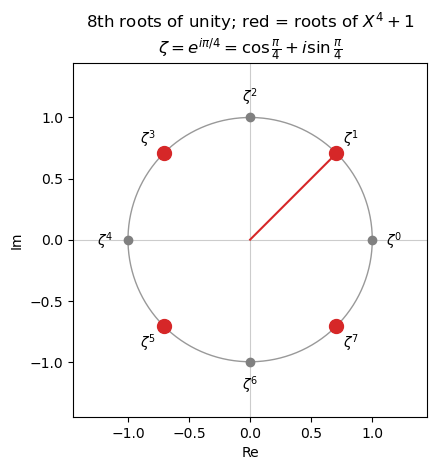

powers of psi = 2 mod 17: [2, 4, 8, 16, 15, 13, 9, 1]  -> order 8, psi^4 = -1
odd powers psi, psi^3, psi^5, psi^7 = [2, 8, 15, 9]   and x^4 + 1 mod 17 at each: [0, 0, 0, 0]


In [97]:
plot_roots_of_unity(N=4)

q, psi = 17, 2
print("powers of psi = 2 mod 17:", [pow(psi, k, q) for k in range(1, 9)], " -> order 8, psi^4 = -1")
roots = [pow(psi, k, q) for k in (1, 3, 5, 7)]
print("odd powers psi, psi^3, psi^5, psi^7 =", roots, "  and x^4 + 1 mod 17 at each:", [(r**4 + 1) % q for r in roots])

## <a id="s2-3"></a>2.3 Tool 4: the Chinese Remainder Theorem, and RNS

If $q=q_1q_2\cdots q_L$ with pairwise-coprime $q_i$, then $\mathbb Z_q\cong\mathbb Z_{q_1}\times\cdots\times\mathbb Z_{q_L}$:
a number is equivalent to its tuple of residues ("limbs"), and $+$ and $\times$ happen **limb by limb**.
Recombination uses $x=\sum_i x_i\,Q_i\,(Q_i^{-1}\bmod q_i) \bmod q$ with $Q_i=q/q_i$.

*Worked example (slide "CRT add and multiply"):* $q=35=5\cdot7$, $x=17$, $y=9$.

In [98]:
mods = [5, 7]
x, y = 17, 9
rx, ry = [x % m_ for m_ in mods], [y % m_ for m_ in mods]
radd = [(u + v) % m_ for u, v, m_ in zip(rx, ry, mods)]
rmul = [(u * v) % m_ for u, v, m_ in zip(rx, ry, mods)]
print(f"x = {x} <-> {tuple(rx)},   y = {y} <-> {tuple(ry)}")
print(f"x + y: limbs {tuple(radd)} -> CRT {crt(radd, mods)}   (direct: {(x + y) % 35})")
print(f"x * y: limbs {tuple(rmul)} -> CRT {crt(rmul, mods)}   (direct: {x * y % 35})")
print("basis constants: 21 <->", (21 % 5, 21 % 7), " 15 <->", (15 % 5, 15 % 7),
      " so (r1, r2) -> 21 r1 + 15 r2 mod 35")

x = 17 <-> (2, 3),   y = 9 <-> (4, 2)
x + y: limbs (1, 5) -> CRT 26   (direct: 26)
x * y: limbs (3, 6) -> CRT 13   (direct: 13)
basis constants: 21 <-> (1, 0)  15 <-> (0, 1)  so (r1, r2) -> 21 r1 + 15 r2 mod 35


**At real size.** CKKS stores a modulus of hundreds of bits as a few word-size primes. Here three
30-bit primes make a 90-bit modulus $Q=q_0q_1q_2$, and a product of two 90-bit numbers is computed with three
independent 30-bit multiplications. The output shows every limb:

1. **split**: $x_i=x\bmod q_i$ and $y_i=y\bmod q_i$ (each fits in one 30-bit word);
2. **multiply limb by limb**: $z_i=x_iy_i\bmod q_i$ (a 60-bit product, reduced back to 30 bits);
3. **recombine** (only when the full number is needed): $x\,y\bmod Q=\sum_i z_i\,Q_i\,(Q_i^{-1}\bmod q_i)\bmod Q$
   with $Q_i=Q/q_i$, the same formula as the $q=35$ example with its constants 21 and 15.

In [99]:
qs3 = ntt_primes(2**16, 30, 3)
Q3 = qs3[0] * qs3[1] * qs3[2]
x, y = 2**89 + 12345, 2**88 + 6789
print(f"primes (30-bit, = 1 mod 2^17): q0, q1, q2 = {qs3[0]:,}, {qs3[1]:,}, {qs3[2]:,}")
print(f"Q = q0 q1 q2 = {Q3}  ({Q3.bit_length()} bits)")
print(f"x = {x}  ({x.bit_length()} bits)")
print(f"y = {y}  ({y.bit_length()} bits)\n")

print("step 1-2: split, then multiply each limb on its own")
rows = [(i, qi, x % qi, y % qi, (x % qi) * (y % qi), (x % qi) * (y % qi) % qi) for i, qi in enumerate(qs3)]
print_table(["limb", "q_i", "x_i = x mod q_i", "y_i = y mod q_i", "x_i * y_i (<= 60 bits)", "z_i = x_i y_i mod q_i"],
            rows, ["", ",", ",", ",", ",", ","])
limbs = [r[-1] for r in rows]

print("\nstep 3: recombine,  x*y mod Q = sum_i z_i * Q_i * (Q_i^-1 mod q_i)  mod Q,   Q_i = Q / q_i")
terms = [(i, Q3 // qi, pow(Q3 // qi, -1, qi), zi * (Q3 // qi) * pow(Q3 // qi, -1, qi))
         for i, (qi, zi) in enumerate(zip(qs3, limbs))]
print_table(["limb", "Q_i = Q / q_i (60 bits)", "Q_i^-1 mod q_i", "term z_i * Q_i * (Q_i^-1 mod q_i)"],
            terms, ["", ",", ",", ","])
result = sum(t[-1] for t in terms) % Q3
print(f"\nsum of terms mod Q    = {result}")
print(f"direct x * y mod Q    = {x * y % Q3}")
print(f"equal: {result == x * y % Q3};  check: (x*y mod Q) mod q_i = {[x * y % Q3 % qi for qi in qs3]} = z_i {limbs}")

primes (30-bit, = 1 mod 2^17): q0, q1, q2 = 1,073,479,681, 1,071,513,601, 1,070,727,169
Q = q0 q1 q2 = 1231601868834905394361663489  (90 bits)
x = 618970019642690137449574457  (90 bits)
y = 309485009821345068724787845  (89 bits)

step 1-2: split, then multiply each limb on its own
limb |           q_i | x_i = x mod q_i | y_i = y mod q_i |  x_i * y_i (<= 60 bits) | z_i = x_i y_i mod q_i
-----+---------------+-----------------+-----------------+-------------------------+----------------------
   0 | 1,073,479,681 |   1,040,459,929 |     520,230,581 | 541,279,073,370,888,749 |           423,227,267
   1 | 1,071,513,601 |     709,284,877 |     354,643,055 | 251,542,955,644,579,235 |           973,626,041
   2 | 1,070,727,169 |     877,938,574 |     974,333,488 | 855,404,953,055,166,112 |           550,255,562

step 3: recombine,  x*y mod Q = sum_i z_i * Q_i * (Q_i^-1 mod q_i)  mod Q,   Q_i = Q / q_i
limb |   Q_i = Q / q_i (60 bits) | Q_i^-1 mod q_i |               term z_i * Q_i * (Q_i^-1 

## <a id="s2-4"></a>2.4 Tool 5: from the DFT to the NTT (*worked example 2/4*)

The **NTT** is the DFT with the complex root replaced by a modular one. For $\mathcal R_q$ we evaluate at the
roots of $X^N+1$:

$$
\mathrm{NTT}(a)=\big(a(\psi),\,a(\psi^3),\,\dots,\,a(\psi^{2N-1})\big),\qquad
a\cdot b=\mathrm{NTT}^{-1}\big(\mathrm{NTT}(a)\odot\mathrm{NTT}(b)\big).
$$

The inverse is interpolation: $a_j=N^{-1}\sum_k \hat a_k\,\psi^{-(2k+1)j} \bmod q$.

In [100]:
q, psi = 17, 2
a = np.array([1, 2, 3, 4]); b = np.array([1, 0, 1, 0])
ah, bh = ntt_eval(a, q, psi), ntt_eval(b, q, psi)
ch = ah * bh % q
print("evaluation point x :", [pow(psi, 2 * k + 1, q) for k in range(4)])
print("a_hat = a(x)       :", ah)
print("b_hat = b(x)       :", bh)
print("c_hat = a_hat*b_hat:", ch, "   <- only N = 4 products")
print("NTT^-1(c_hat)      :", intt_eval(ch, q, psi), "  == schoolbook", negacyclic_schoolbook(a, b, q)[1])

evaluation point x : [2, 8, 15, 9]
a_hat = a(x)       : [15 13 11 16]
b_hat = b(x)       : [ 5 14  5 14]
c_hat = a_hat*b_hat: [ 7 12  4  3]    <- only N = 4 products
NTT^-1(c_hat)      : [15 15  4  6]   == schoolbook [15 15  4  6]


## <a id="s2-5"></a>2.5 The NTT *is* the CRT of polynomials: butterflies (*worked examples 3/4 and 4/4*)

Mod 17, $X^4+1=(X^2-4)(X^2+4)=(X-2)(X+2)(X-8)(X+8)$. Each split is one CRT step. Writing
$a=\ell+X^m h$ (low and high halves), reducing modulo $X^m\mp w$ gives $\ell\pm w\,h$: a **butterfly**
$(x,y)\mapsto(x+wy,\;x-wy)$. Going back up is the inverse butterfly $\ell=(x+y)/2$, $h=(x-y)/(2w)$.

In [101]:
q = 17
print("forward (split), a = 1 + 2X + 3X^2 + 4X^3:")
L, H = split(a, 4, q)
print(f"   mod X^2-4: {poly_str(L)}      mod X^2+4: {poly_str(H)}")
leaves_a = [*split(L, 2, q), *split(H, 8, q)]
print("   leaves mod X-2, X+2, X-8, X+8 =", [int(v[0]) for v in leaves_a], " = a(2), a(15), a(8), a(9)")
Lb, Hb = split(b, 4, q)
leaves_b = [*split(Lb, 2, q), *split(Hb, 8, q)]                 # b = 1 + X^2 through the same tree
prod = [int(u[0]) * int(v[0]) % q for u, v in zip(leaves_a, leaves_b)]
print("multiply leaves: c_hat =", prod)
print("inverse (merge):")
Lc = merge(np.array([prod[0]]), np.array([prod[1]]), 2, q)
Hc = merge(np.array([prod[2]]), np.array([prod[3]]), 8, q)
print(f"   mod X^2-4: {poly_str(Lc)}      mod X^2+4: {poly_str(Hc)}")
print("   c =", poly_str(merge(Lc, Hc, 4, q)), "  == schoolbook 15 + 15X + 4X^2 + 6X^3")

forward (split), a = 1 + 2X + 3X^2 + 4X^3:
   mod X^2-4: 13 + X      mod X^2+4: 6 + 3X
   leaves mod X-2, X+2, X-8, X+8 = [15, 11, 13, 16]  = a(2), a(15), a(8), a(9)
multiply leaves: c_hat = [7, 4, 12, 3]
inverse (merge):
   mod X^2-4: 14 + 5X      mod X^2+4: 16 + 8X
   c = 15 + 15X + 4X^2 + 6X^3   == schoolbook 15 + 15X + 4X^2 + 6X^3


### The fast NTT at real size

Doing every level of that tree for all blocks at once gives the Cooley–Tukey NTT:
$\log_2N$ levels of $N/2$ butterflies, i.e. $O(N\log N)$ instead of $N^2$. The output comes out in
**bit-reversed** order, $2,15,8,9$ instead of $2,8,15,9$. The inverse (Gentleman–Sande) runs the tree
upward and folds all the $1/2$ factors into one final multiply by $N^{-1}$.

In [102]:
print("N = 4 toy:  ntt(a) =", ntt(a, 17, 2), " (the tree's leaves, bit-reversed)   intt(ntt(a)) =", intt(ntt(a, 17, 2), 17, 2))

Nb = 1024
qb = ntt_primes(Nb, 25, 1)[0]; psib = primitive_2N_root(qb, Nb)
x_ = rng.integers(0, qb, Nb); y_ = rng.integers(0, qb, Nb)
fast = intt(ntt(x_, qb, psib) * ntt(y_, qb, psib) % qb, qb, psib)
slow = np.mod(negacyclic_schoolbook(centered(x_, qb), centered(y_, qb))[1], qb)
print(f"N = 1024, q = {qb}: NTT-based product == schoolbook product: {np.array_equal(fast, slow)}\n")

rows = []
for logN in (10, 12, 14, 16):
    N_ = 2**logN
    q_ = ntt_primes(N_, 30, 1)[0]; p_ = primitive_2N_root(q_, N_)
    v_ = rng.integers(0, q_, N_)
    V_, dt = timed(ntt, v_, q_, p_)
    assert np.array_equal(intt(V_, q_, p_), v_)
    rows.append((N_, N_ * N_, N_ // 2 * logN, f"{N_ * N_ / (N_ // 2 * logN):,.0f}x", f"{dt * 1e3:.1f} ms"))
print_table(["N", "schoolbook products", "NTT butterflies", "ratio", "our NTT time"], rows, [",", ",", ",", "", ""])

N = 4 toy:  ntt(a) = [15 11 13 16]  (the tree's leaves, bit-reversed)   intt(ntt(a)) = [1 2 3 4]
N = 1024, q = 33550337: NTT-based product == schoolbook product: True

     N | schoolbook products | NTT butterflies |  ratio | our NTT time
-------+---------------------+-----------------+--------+-------------
 1,024 |           1,048,576 |           5,120 |   205x |       1.0 ms
 4,096 |          16,777,216 |          24,576 |   683x |       4.0 ms
16,384 |         268,435,456 |         114,688 | 2,341x |      14.6 ms
65,536 |       4,294,967,296 |         524,288 | 8,192x |      62.9 ms


## <a id="s2-6"></a>2.6 RNS + NTT = double-CRT

Put both CRTs together, as a CKKS library does. A polynomial with a 90-bit modulus is split into three
30-bit limbs (integer CRT), and each limb goes through its own NTT (polynomial CRT). The ring product then
becomes $3\times N$ independent word-size multiplications, the $L\times N$ grid of the *Double-CRT* slide.
Below, the result is checked against exact big-integer schoolbook multiplication.

In [103]:
N = 64
qs3 = ntt_primes(N, 30, 3); Q3 = qs3[0] * qs3[1] * qs3[2]
xa = [int(v) * 12345 % Q3 for v in rng.integers(0, 2**62, N)]
ya = [int(v) * 67891 % Q3 for v in rng.integers(0, 2**62, N)]
exact = [v % Q3 for v in negacyclic_exact(xa, ya)]         # big-int schoolbook, the slow reference

limb_products = []
for qi in qs3:                                             # each limb: word-size numbers only
    pi = primitive_2N_root(qi, N)
    xi = np.array([v % qi for v in xa], dtype=np.int64)
    yi = np.array([v % qi for v in ya], dtype=np.int64)
    limb_products.append(intt(ntt(xi, qi, pi) * ntt(yi, qi, pi) % qi, qi, pi))
recombined = [crt([lp[k] for lp in limb_products], qs3) for k in range(N)]

print(f"Q = {' x '.join(map(str, qs3))}  ({Q3.bit_length()} bits),  N = {N}")
rns_bits, coeff_bits = len(qs3) * N * 30, N * Q3.bit_length()
print(f"storage: {len(qs3)} limbs x {N} NTT coordinates = {len(qs3) * N} words of 30 bits = {rns_bits:,} bits;"
      f"  the polynomial itself: {N} coefficients x {Q3.bit_length()} bits = {coeff_bits:,} bits"
      f"  ->  {expansion(rns_bits, coeff_bits)} (RNS changes the layout, not the size)")
print("double-CRT product == exact big-integer product:", recombined == exact)

Q = 1073741441 x 1073739649 x 1073738753  (90 bits),  N = 64
storage: 3 limbs x 64 NTT coordinates = 192 words of 30 bits = 5,760 bits;  the polynomial itself: 64 coefficients x 90 bits = 5,760 bits  ->  1.0x (RNS changes the layout, not the size)
double-CRT product == exact big-integer product: True


---
# <a id="s3"></a>3. CKKS, step by step

<small>[&uarr; back to contents](#contents)</small>

This section follows the *CKKS Scheme* slides and reproduces their examples with running code:
encoding ($N=4$), SIMD slots ($N=8$), the scale $\Delta$, and the full toy workflow
($N=8$, $\Delta=10$, $Q=17\cdot97$) from encoding to decoding. The workflow's printouts match
*Workflow 1–5* number for number, and `assert` statements check this. The section ends with rotations and the
cross-limb kernels.

The parameters are tiny and **completely insecure** (zero noise, fixed "random" values), so every value can be
checked by hand. Section 4 moves to real parameters with OpenFHE.

In [104]:
# ---- Section 3 helpers: the CKKS encoder, and the slides' toy double-CRT arithmetic
def slot_exponents(N, order="direct"):
    # Exponents e (of zeta = e^{i pi/N}) that carry the N/2 slots, followed by their conjugates 2N - e.
    #   "direct": zeta^1, zeta^3, ..., zeta^(N-1)   (the slides' toy order)
    #   "rot"   : zeta^(5^j)                       (what libraries use: rotations become cyclic shifts)
    e = [2 * j + 1 for j in range(N // 2)] if order == "direct" else [pow(5, j, 2 * N) for j in range(N // 2)]
    return np.array(e + [2 * N - x for x in e])

def sigma_matrix(N, order="direct"):
    zeta = np.exp(1j * np.pi / N)
    return zeta ** np.outer(slot_exponents(N, order), np.arange(N))     # row k: evaluate at one root

def encode(z, Delta, N, order="direct"):
    z = np.asarray(z, dtype=complex)
    m = np.linalg.solve(sigma_matrix(N, order), np.concatenate([z, np.conj(z)])).real
    return np.floor(Delta * m + 0.5 + 1e-9).astype(np.int64)          # round half up, as on the slides

def decode(m, Delta, N, order="direct"):
    return (sigma_matrix(N, order) @ np.asarray(m, dtype=float))[: N // 2] / Delta

def plot_precision(logs, err_enc, err_mul, N):
    plt.figure(figsize=(6, 3.2))
    plt.semilogy(list(logs), err_enc, "o-", label="encode -> decode")
    plt.semilogy(list(logs), err_mul, "s-", label="multiply -> rescale -> decode")
    plt.semilogy(list(logs), [2.0**-lg for lg in logs], "k--", lw=1, label=r"$1/\Delta$")
    plt.xlabel(r"$\log_2\Delta$  (scale bits)"); plt.ylabel("max error in any slot")
    plt.title(f"CKKS precision vs. scale  (N = {N}, {N // 2} slots)"); plt.grid(alpha=0.3); plt.legend(); plt.show()

# The slides' toy RNS basis: Q = 17 * 97, primitive 16th roots psi_0 = 3, psi_1 = 8.
# A polynomial is stored as a (limbs x NTT coordinates) array; coordinate k is its value at psi^(2k+1).
qs, psis = [17, 97], [3, 8]
Q = qs[0] * qs[1]
QS = np.array(qs)[:, None]                                   # broadcast "mod q_i" over each limb row

def to_dcrt(m):                                              # coefficients -> (limbs x NTT coordinates)
    return np.stack([ntt_eval(np.mod(m, qi), qi, pi) for qi, pi in zip(qs, psis)])

def from_dcrt(H):                                            # INTT per limb, CRT, centered coefficients
    limbs = [intt_eval(h, qi, pi) for h, qi, pi in zip(H, qs, psis)]
    return centered(np.array([crt([l[j] for l in limbs], qs) for j in range(len(H[0]))]), Q)

def encrypt(M, U, pk):                                       # ct = (m + b u + e0, a u + e1), here e0 = e1 = 0
    B, A = pk
    return (M + B * U) % QS, (A * U) % QS

def decrypt(ct, S):                                          # c0 + c1 s: one ring element, still double-CRT
    return (ct[0] + ct[1] * S) % QS

def ct_add(x, y):
    return (x[0] + y[0]) % QS, (x[1] + y[1]) % QS

def ct_mult(x, y):                                           # 3 components, under (1, s, s^2)
    return x[0] * y[0] % QS, (x[0] * y[1] + x[1] * y[0]) % QS, x[1] * y[1] % QS

def relinearize(d, rlk):                                     # (d0, d1, d2) -> (d0 + d2 beta, d1 + d2 alpha)
    beta, alpha = rlk
    return (d[0] + d[2] * beta) % QS, (d[1] + d[2] * alpha) % QS

def automorphism(m, g):
    # tau_g on coefficients: X^j -> X^(g j), reduced with X^N = -1.
    out = np.zeros_like(m)
    for j, c in enumerate(m):
        e = g * j % (2 * len(m))
        if e < len(m):
            out[e] += c
        else:
            out[e - len(m)] -= c
    return out

def ntt_permutation(g, N):
    # tau_g on NTT coordinates: new[k] = old[k'] with 2k'+1 = g(2k+1) mod 2N.
    return np.array([(g * (2 * k + 1) % (2 * N) - 1) // 2 for k in range(N)])

def galois_key(g, S):                                        # one-digit toy key: beta + alpha s = tau_g(s)
    alpha_g = to_dcrt(rng.integers(0, Q, S.shape[1]))
    return (S[:, ntt_permutation(g, S.shape[1])] - alpha_g * S) % QS, alpha_g

def rotate(ct, g, key):
    p = ntt_permutation(g, ct[0].shape[1])
    c0, c1 = ct[0][:, p], ct[1][:, p]                        # tau_g: permute both components (cheap)
    return relinearize((c0, np.zeros_like(c0), c1), key)     # key switch back to s (the expensive part)

def mod_up(res_Q, Q_mods, P_mods):
    # Add residues modulo new primes p_j of the same integer (CRT lift, then reduce).
    x_ = crt(res_Q, Q_mods)
    return list(res_Q) + [x_ % p for p in P_mods]

def mod_down(res, Q_mods, P_mods):
    # Divide by P = prod(P_mods) and round:  y_i = (x_i - r) * P^{-1} mod q_i,  r = centered remainder mod P.
    P = int(np.prod(P_mods))
    r = int(centered(crt(res[len(Q_mods):], P_mods), P))
    return [(int(x_) - r) * pow(P, -1, qi) % qi for x_, qi in zip(res[:len(Q_mods)], Q_mods)]

def rescale(res, mods):
    # CKKS rescale = ModDown by the last chain prime: one limb and one level are consumed.
    return mod_down(res, mods[:-1], mods[-1:])

## <a id="s3-1"></a>3.1 Encoding: slots $\to$ polynomial (the canonical embedding)

$\sigma$ evaluates a polynomial at the primitive $2N$-th roots of unity. A real polynomial's values come in
conjugate pairs, so it carries $N/2$ free complex **slots**. Encoding inverts $\sigma$, scales and rounds:

$$
m(X)=\big\lfloor\Delta\cdot\sigma^{-1}(z)\big\rceil\in\mathcal R,\qquad
\mathrm{Decode}(m)=\sigma(m)/\Delta .
$$

*Slide example:* $N=4$, $z=(1+2i,\,3+4i)$, no scaling, gives $p(X)=2+\sqrt2X-X^2+2\sqrt2X^3$.

In [105]:
p = np.linalg.solve(sigma_matrix(4), np.array([1 + 2j, 3 + 4j, 1 - 2j, 3 - 4j])).real
print("p(X) coefficients:", np.round(p, 4), "  = (2, sqrt2, -1, 2 sqrt2)")
zeta = np.exp(1j * np.pi / 4)
print("p(zeta) =", np.round(np.polyval(p[::-1], zeta), 6), "  p(zeta^3) =", np.round(np.polyval(p[::-1], zeta**3), 6))

p(X) coefficients: [ 2.      1.4142 -1.      2.8284]   = (2, sqrt2, -1, 2 sqrt2)
p(zeta) = (1+2j)   p(zeta^3) = (3+4j)


## <a id="s3-2"></a>3.2 Slots are SIMD lanes

*Slide example ($N=8$, four slots):* $z=(0.1,4.1,-18.7,2.0)$ and $w=(2.0,-1.0,0.5,3.0)$.
The polynomial product $m_z\cdot m_w$ in $\mathcal R$ decodes to the **slot-wise** product $z\odot w$,
at scale $\Delta^2$. Compare Section 1.4, where multiplying bit-polynomials gave a polynomial product: the
canonical embedding turns ring multiplication into SIMD. Note also that a slot is not a coefficient.

In [106]:
N, Delta = 8, 2**20
z = np.array([0.1, 4.1, -18.7, 2.0]); w = np.array([2.0, -1.0, 0.5, 3.0])
m_z, m_w = encode(z, Delta, N), encode(w, Delta, N)
m_prod = negacyclic_schoolbook(m_z, m_w)[1]                # ring product in Z[X]/(X^8 + 1)

print("coefficients of m_z :", m_z, "  <- every slot is spread over all 8")
print("decode(m_z + m_w)   :", np.round(decode(m_z + m_w, Delta, N).real, 4), "  z + w =", z + w)
print("decode(m_z * m_w)   :", np.round(decode(m_prod, Delta**2, N).real, 4), "  z (.) w =", z * w)

coefficients of m_z : [-3276800  1827094  3095575 -5712525        0  5712525 -3095575 -1827094]   <- every slot is spread over all 8
decode(m_z + m_w)   : [  2.1   3.1 -18.2   5. ]   z + w = [  2.1   3.1 -18.2   5. ]
decode(m_z * m_w)   : [ 0.2  -4.1  -9.35  6.  ]   z (.) w = [ 0.2  -4.1  -9.35  6.  ]


## <a id="s3-3"></a>3.3 The scale $\Delta$: fixed-point precision

The rounding in `encode` is the first source of CKKS error. It is about $1/\Delta$ in each slot, so every extra
bit of $\Delta$ buys one bit of precision (slide *Fixed point with noise in the LSBs*). A product has scale
$\Delta^2$. **Rescaling** divides by $\approx\Delta$ and rounds, which brings it back to $\Delta$ at the cost of
one more rounding.

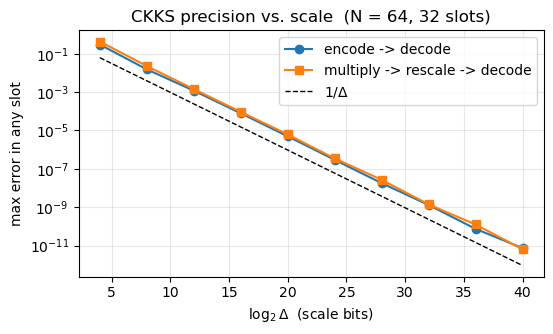

In [107]:
N = 64
z = rng.uniform(-1, 1, N // 2); w = rng.uniform(-1, 1, N // 2)
logs, err_enc, err_mul = range(4, 41, 4), [], []
for lg in logs:
    D = 2**lg
    mz, mw = encode(z, D, N), encode(w, D, N)
    err_enc.append(np.abs(decode(mz, D, N) - z).max())
    prod = negacyclic_exact(mz, mw)                                   # scale D^2
    rescaled = np.array([(v + D // 2) // D for v in prod], dtype=float)   # rescale: divide by D, round
    err_mul.append(np.abs(decode(rescaled, D, N) - z * w).max())
plot_precision(logs, err_enc, err_mul, N)

## <a id="s3-4"></a>3.4 The toy workflow, end to end (*Example workflow* and *Workflow 1–5*)

Parameters from the slides: $N=8$ (four slots), $\Delta=10$, $Q=q_0q_1=17\cdot97$ with primitive 16th roots
$\psi_0=3$, $\psi_1=8$; inputs $z=(1.0,2.1,3.0,2.5)$ and $w=(1.2,2.2,3.1,2.6)$.
Every polynomial is stored as the slides' **double-CRT** array: 2 limbs $\times$ 8 NTT coordinates
(`ntt_eval` from Section 2.4, so coordinate $k$ is the value at $\psi^{2k+1}$).
The slides trace coordinate $k=0$; here all eight are computed.

In [108]:
# ---- Workflow 1 (client): encode, split into limbs, NTT      (toy RNS basis Q = 17 * 97 from the helper cell)
N, Delta = 8, 10
z = np.array([1.0, 2.1, 3.0, 2.5]); w = np.array([1.2, 2.2, 3.1, 2.6])
m_z, m_w = encode(z, Delta, N), encode(w, Delta, N)
Mz, Mw = to_dcrt(m_z), to_dcrt(m_w)
print("m_z =", m_z, "   decode(m_z) =", np.round(decode(m_z, Delta, N).real, 3))
print("m_w =", m_w, "   decode(m_w) =", np.round(decode(m_w, Delta, N).real, 3))
print("m_z mod 17 =", np.mod(m_z, 17), "   m_z mod 97 =", np.mod(m_z, 97))
print("NTT(m_z):  q0 row", Mz[0], "  q1 row", Mz[1])
print("NTT(m_w):  q0 row", Mw[0], "  q1 row", Mw[1], "  (= NTT(m_z) + 1)")
assert list(m_z) == [22, -4, -3, 1, 0, -1, 3, 4] and list(Mz[:, 0]) == [9, 41] and list(Mw[:, 0]) == [10, 42]

m_z = [22 -4 -3  1  0 -1  3  4]    decode(m_z) = [1.113 2.133 3.115 2.438]
m_w = [23 -4 -3  1  0 -1  3  4]    decode(m_w) = [1.213 2.233 3.215 2.538]
m_z mod 17 = [ 5 13 14  1  0 16  3  4]    m_z mod 97 = [22 93 94  1  0 96  3  4]
NTT(m_z):  q0 row [ 9  9 16  3  3 16  9  9]   q1 row [41 82 46 16 16 46 82 41]
NTT(m_w):  q0 row [10 10  0  4  4  0 10 10]   q1 row [42 83 47 17 17 47 83 42]   (= NTT(m_z) + 1)


In [109]:
# ---- Workflow 2 (client): keys and encryption  (all errors 0: an exact, insecure trace)
s = np.array([-1, 1, 0, 0, -1, 1, -1, -1])                  # s(X) = -1 + X - X^4 + X^5 - X^6 - X^7
S = to_dcrt(s)
a = rng.integers(0, Q, N)                                    # uniform a, with a_hat = 5 at k = 0 as on the slide
a[0] = crt([(5 - sum(int(a[j]) * pow(pi, j, qi) for j in range(1, N))) % qi for qi, pi in zip(qs, psis)], qs)
A = to_dcrt(a)
pk = ((-A * S) % QS, A)                                      # pk = (b, a) with b = -a s + e,  e = 0

u_z = np.array([-1, -1, -1, 1, 1, -1, 0, -1])                # the slides' ternary masks
u_w = np.array([1, -1, 0, -1, 1, -1, -1, -1])
ct_z, ct_w = encrypt(Mz, to_dcrt(u_z), pk), encrypt(Mw, to_dcrt(u_w), pk)

ct_words = 2 * ct_z[0].size
print(f"sizes: message = {len(z)} slot values;  plaintext polynomial = {Mz.shape} (limbs x coordinates) = {Mz.size} words;"
      f"  ciphertext = 2 components x {ct_z[0].shape} = {ct_words} words")
print(f"growth: ciphertext / plaintext polynomial = {expansion(ct_words, Mz.size)},"
      f"  ciphertext / message = {expansion(ct_words, len(z))}\n")
print("coordinate k = 0 (the slide's table):")
pair = lambda x, y: f"({x}, {y})"
print_table(["limb", "s_hat", "pk = (b, a)", "ct_z", "ct_w", "c0 + c1 s_hat", "= NTT values"],
            [(f"q={qi}", S[i, 0], pair(pk[0][i, 0], A[i, 0]), pair(ct_z[0][i, 0], ct_z[1][i, 0]),
              pair(ct_w[0][i, 0], ct_w[1][i, 0]), f"{decrypt(ct_z, S)[i, 0]}, {decrypt(ct_w, S)[i, 0]}",
              f"{Mz[i, 0]}, {Mw[i, 0]}") for i, qi in enumerate(qs)])
assert [(ct_z[0][i, 0], ct_z[1][i, 0]) for i in range(2)] == [(1, 4), (27, 7)]
assert [(ct_w[0][i, 0], ct_w[1][i, 0]) for i in range(2)] == [(4, 3), (20, 11)]

sizes: message = 4 slot values;  plaintext polynomial = (2, 8) (limbs x coordinates) = 16 words;  ciphertext = 2 components x (2, 8) = 32 words
growth: ciphertext / plaintext polynomial = 2.0x,  ciphertext / message = 8.0x

coordinate k = 0 (the slide's table):
limb | s_hat | pk = (b, a) |    ct_z |     ct_w | c0 + c1 s_hat | = NTT values
-----+-------+-------------+---------+----------+---------------+-------------
q=17 |     2 |      (7, 5) |  (1, 4) |   (4, 3) |         9, 10 |        9, 10
q=97 |     2 |     (87, 5) | (27, 7) | (20, 11) |        41, 42 |       41, 42


In [110]:
# ---- Workflow 3 (server): add and multiply, every (limb, coordinate) cell independently
ct_sum = ct_add(ct_z, ct_w)
d = ct_mult(ct_z, ct_w)                                      # 3 components, under (1, s, s^2)
for i, qi in enumerate(qs):
    print(f"q={qi:<3} k=0:  add -> ({ct_sum[0][i, 0]:>2}, {ct_sum[1][i, 0]:>2})"
          f"    multiply -> ({d[0][i, 0]}, {d[1][i, 0]}, {d[2][i, 0]})"
          f"  decrypts to {(d[0][i, 0] + d[1][i, 0] * S[i, 0] + d[2][i, 0] * S[i, 0] ** 2) % qi}"
          f" = {Mz[i, 0]} * {Mw[i, 0]} mod {qi}")
assert [(d[0][i, 0], d[1][i, 0], d[2][i, 0]) for i in range(2)] == [(4, 2, 12), (55, 49, 77)]

# ---- Workflow 4 (server): relinearize with rlk = (beta, alpha), beta + alpha s = s^2   (one-digit toy key)
rlk = ((S * S - A * S) % QS, A)                              # the slide uses alpha_hat = 5 at k = 0
ct_prod = relinearize(d, rlk)
for i, qi in enumerate(qs):
    print(f"q={qi:<3} k=0:  rlk = ({rlk[0][i, 0]}, {rlk[1][i, 0]})   relinearized -> ({ct_prod[0][i, 0]}, {ct_prod[1][i, 0]})"
          f"  decrypts to {decrypt(ct_prod, S)[i, 0]}")
assert [(ct_prod[0][i, 0], ct_prod[1][i, 0]) for i in range(2)] == [(0, 11), (78, 46)]

q=17  k=0:  add -> ( 5,  7)    multiply -> (4, 2, 12)  decrypts to 5 = 9 * 10 mod 17
q=97  k=0:  add -> (47, 18)    multiply -> (55, 49, 77)  decrypts to 73 = 41 * 42 mod 97
q=17  k=0:  rlk = (11, 5)   relinearized -> (0, 11)  decrypts to 5
q=97  k=0:  rlk = (91, 5)   relinearized -> (78, 46)  decrypts to 73


In [111]:
# ---- Workflow 5 (client): decrypt, INTT, CRT, decode
for name, ct, scale, ideal in [("z + w", ct_sum, Delta, z + w), ("z * w", ct_prod, Delta**2, z * w)]:
    H = decrypt(ct, S)
    coeffs = from_dcrt(H)
    print(f"{name}:  decrypted NTT rows  q0 {H[0]}  q1 {H[1]}")
    print(f"        INTT + CRT + center -> {coeffs}")
    print(f"        decode (scale {scale}) -> {np.round(decode(coeffs, scale, N).real, 3)}   ideal {ideal}\n")
assert list(from_dcrt(decrypt(ct_sum, S))) == [45, -8, -6, 2, 0, -2, 6, 8]
assert list(from_dcrt(decrypt(ct_prod, S))) == [558, -162, -128, 75, 0, -75, 128, 162]
print("All values match the slides (Workflow 1-5).")

z + w:  decrypted NTT rows  q0 [ 2  2 16  7  7 16  2  2]  q1 [83 68 93 33 33 93 68 83]
        INTT + CRT + center -> [45 -8 -6  2  0 -2  6  8]
        decode (scale 10) -> [2.326 4.367 6.33  4.977]   ideal [2.2 4.3 6.1 5.1]

z * w:  decrypted NTT rows  q0 [ 5  5  0 12 12  0  5  5]  q1 [73 16 28 78 78 28 16 73]
        INTT + CRT + center -> [ 558 -162 -128   75    0  -75  128  162]
        decode (scale 100) -> [ 1.35   4.764 10.016  6.189]   ideal [1.2  4.62 9.3  6.5 ]

All values match the slides (Workflow 1-5).


The results are $\approx$ the ideal answers but not equal to them. Decryption, INTT and CRT are exact here; the
gap is the rounding at the tiny scale $\Delta=10$ (Section 3.3). A real CKKS multiply would also **rescale**,
dividing by a chain prime to go from $\Delta^2$ back to $\approx\Delta$ (Section 3.6).

## <a id="s3-5"></a>3.5 Rotation: a cheap permutation plus a key switch

With the slots ordered by powers of 5 ($z_j = m(\zeta^{5^j})$), the automorphism $\tau_g: m(X)\mapsto m(X^g)$ with
$g=5^r \bmod 2N$ **shifts the slots left by $r$**. On stored data it is just a permutation of the NTT coordinates.
The catch: $\tau_g(\mathrm{ct})$ decrypts under $\tau_g(s)$. A **key switch** with a Galois key
$\mathrm{gk}_g=(\beta,\alpha)$, where $\beta+\alpha s=\tau_g(s)$, brings it back under $s$.
We then run the slide's rotate-and-add, which sums all four slots.

In [112]:
z = np.array([1.0, 2.1, 3.0, 2.5])
m_r = encode(z, Delta, N, order="rot")
print("encoded slots          :", np.round(decode(m_r, Delta, N, "rot").real, 3))
for r in (1, 2):
    g = pow(5, r, 2 * N)
    print(f"tau_{g} (rotate by {r})  :", np.round(decode(automorphism(m_r, g), Delta, N, "rot").real, 3))
same = np.array_equal(to_dcrt(automorphism(m_r, 5)), to_dcrt(m_r)[:, ntt_permutation(5, N)])
print("tau_5 == permutation of NTT coordinates:", same, "  permutation:", ntt_permutation(5, N))

encoded slots          : [1.09  2.093 3.027 2.59 ]
tau_5 (rotate by 1)  : [2.093 3.027 2.59  1.09 ]
tau_9 (rotate by 2)  : [3.027 2.59  1.09  2.093]
tau_5 == permutation of NTT coordinates: True   permutation: [2 7 4 1 6 3 0 5]


In [113]:
ct_r = encrypt(to_dcrt(m_r), to_dcrt(rng.integers(-1, 2, N)), pk)
show = lambda ct, digits=3: np.round(decode(from_dcrt(decrypt(ct, S)), Delta, N, "rot").real, digits)

p5 = ntt_permutation(5, N)
wrong = (ct_r[0][:, p5] + ct_r[1][:, p5] * S) % QS          # tau_5(ct), decrypted with the old key s
print("tau_5(ct) decrypted with s   :", np.round(decode(from_dcrt(wrong), Delta, N, "rot").real, 1), " <- wrong key")
gk5, gk9 = galois_key(5, S), galois_key(9, S)
print("after key switch, with s     :", show(rotate(ct_r, 5, gk5)))

t1 = ct_add(ct_r, rotate(ct_r, 5, gk5))                     # t1 = z + Rot_1(z)
t2 = ct_add(t1, rotate(t1, 9, gk9))                         # t2 = t1 + Rot_2(t1)
print("rotate-and-add, t1           :", show(t1))
print("rotate-and-add, t2           :", show(t2))
enc_sum = decode(m_r, Delta, N, "rot").real.sum()
print(f"sum of the encoded slots = {enc_sum:.3f}  (the ideal sum is {z.sum():.1f}; the gap is encoding rounding at Delta = 10)")

tau_5(ct) decrypted with s   : [  9.1 -64.6  66.4  19. ]  <- wrong key
after key switch, with s     : [2.093 3.027 2.59  1.09 ]
rotate-and-add, t1           : [3.183 5.121 5.617 3.679]
rotate-and-add, t2           : [8.8 8.8 8.8 8.8]
sum of the encoded slots = 8.800  (the ideal sum is 8.6; the gap is encoding rounding at Delta = 10)


## <a id="s3-6"></a>3.6 The cross-limb kernels: ModUp, ModDown, Rescale

These are the only operations where one output residue depends on **all** limbs of a coefficient
(slide *The cross-limb kernels*). The numbers below are the slide's toy examples.

In [114]:
print("ModUp   558 = (14, 73) mod (17, 97)  ->", mod_up([558 % 17, 558 % 97], [17, 97], [113]), "  mod (17, 97, 113)")
X = 113 * 558 + 20
res_X = [X % 17, X % 97, X % 113]
print(f"ModDown X = 113*558 + 20 = {res_X}  ->", mod_down(res_X, [17, 97], [113]),
      f"= 558;  just dropping the p row gives {res_X[:2]} = {crt(res_X[:2], [17, 97])}")
c, D_in = 85, 170
print(f"Rescale c = {c} at scale {D_in} (= 0.5): residues {[c % 97, c % 17]} mod (97, 17)  ->",
      rescale([c % 97, c % 17], [97, 17]), f"mod 97 at scale {D_in // 17}:  5 / 10 = 0.5")

ModUp   558 = (14, 73) mod (17, 97)  -> [14, 73, 106]   mod (17, 97, 113)
ModDown X = 113*558 + 20 = [4, 24, 20]  -> [14, 73] = 558;  just dropping the p row gives [4, 24] = 412
Rescale c = 85 at scale 170 (= 0.5): residues [85, 0] mod (97, 17)  -> [5] mod 97 at scale 10:  5 / 10 = 0.5


## <a id="s3-7"></a>3.7 Summary and next step

| Step | What the code did | Kernel |
|---|---|---|
| encode / decode | $\sigma^{-1}$, $\times\Delta$, round  /  $\sigma$, $\div\Delta$ | special FFT over $\mathbb C$ |
| to double-CRT | reduce mod each $q_i$, NTT per limb | integer CRT + NTT |
| encrypt / add / multiply | element-wise on the $2\times L\times N$ array | element-wise mod-mul/add |
| relinearize, rotate | key switch (here: one-digit toy keys) | NTT + BConv + MAC |
| rescale, ModUp / ModDown | CRT basis conversion | cross-limb |

**Section 4** repeats this with OpenFHE at real parameters ($N=2^{16}$, $\approx1500$-bit $Q$), including
bootstrapping and timing. It needs `openfhe-python` built against the local OpenFHE install.

---
# <a id="s4"></a>4. CKKS at real parameters with OpenFHE

<small>[&uarr; back to contents](#contents)</small>

Sections 0–3 used toy numbers so every value could be checked by hand. This section runs the same
operations in **OpenFHE 1.4.2**, the library in `../openfhe`, at 128-bit security. It covers how the
multiplicative depth fixes $N$ and $Q$, precision, levels, ciphertext and key sizes, timing on this laptop,
and bootstrapping.

## <a id="s4-0"></a>4.0 Setup: which OpenFHE this uses

* **OpenFHE 1.4.2, Release build**, installed in `../openfhe/build-release/install`.
  The copy in `/usr/local` is a *Debug* build (`CMAKE_BUILD_TYPE=Debug`), which is far slower, so it is not
  used here.
* **openfhe-python v1.4.2.2**, cloned to `../openfhe-python` and installed in `../openfhe-python/install`.
  Its `openfhe/lib` is a symlink to the Release libraries above. Nothing is installed into the Python environment:
  the next cell simply adds that folder to `sys.path`.

How it was built (macOS, Apple clang, Homebrew `libomp`):

```bash
SDK=$(xcrun --show-sdk-path); OMP=/opt/homebrew/opt/libomp
# The -nostdinc++ / -isystem flags work around stale C++ headers in
# /Library/Developer/CommandLineTools/usr/include/c++ that hide the SDK's libc++.
FIX="-nostdinc++ -isystem $SDK/usr/include/c++/v1"

cmake -S ../openfhe -B ../openfhe/build-release -DCMAKE_BUILD_TYPE=Release \
      -DCMAKE_INSTALL_PREFIX=$PWD/../openfhe/build-release/install \
      -DBUILD_UNITTESTS=OFF -DBUILD_EXAMPLES=OFF -DBUILD_BENCHMARKS=OFF -DWITH_OPENMP=ON \
      -DOpenMP_C_FLAGS="-Xpreprocessor -fopenmp -I$OMP/include" -DOpenMP_CXX_FLAGS="-Xpreprocessor -fopenmp -I$OMP/include" \
      -DOpenMP_C_LIB_NAMES=omp -DOpenMP_CXX_LIB_NAMES=omp -DCMAKE_SHARED_LINKER_FLAGS="-L$OMP/lib" \
      -DCMAKE_OSX_SYSROOT="$SDK" -DCMAKE_CXX_FLAGS="$FIX"
make -C ../openfhe/build-release -j8 install

git clone --depth 1 --branch v1.4.2.2 https://github.com/openfheorg/openfhe-python ../openfhe-python
cmake -S ../openfhe-python -B ../openfhe-python/build -DCMAKE_BUILD_TYPE=Release \
      -DOpenFHE_DIR=$PWD/../openfhe/build-release/install/lib/OpenFHE \
      -Dpybind11_DIR=$(python -m pybind11 --cmakedir) -DPYTHON_EXECUTABLE_PATH=$(which python) \
      -DCMAKE_INSTALL_PREFIX=$PWD/../openfhe-python/install/openfhe -DCMAKE_CXX_FLAGS="$FIX" \
      -DCMAKE_MODULE_LINKER_FLAGS="-L$OMP/lib"
make -C ../openfhe-python/build -j8 install
ln -s ../../../openfhe/build-release/install/lib ../openfhe-python/install/openfhe/lib
```

In [115]:
# ---- Section 4 helpers: load openfhe-python, build contexts and keys, measure sizes and time
import os, sys, tempfile, platform
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve() / "openfhe-python" / "install"))
import openfhe as fhe

F = fhe.PKESchemeFeature
MAX_LOG_QP = {2**10: 27, 2**11: 54, 2**12: 109, 2**13: 218, 2**14: 438, 2**15: 881, 2**16: 1747, 2**17: 3523}

def make_context(depth, scale_bits=50, first_bits=60, security=fhe.SecurityLevel.HEStd_128_classic,
                 technique=fhe.ScalingTechnique.FLEXIBLEAUTO, ring_dim=None):
    # A CKKS context: `depth` chain primes of `scale_bits` bits on top of a `first_bits` base prime.
    p = fhe.CCParamsCKKSRNS()
    p.SetMultiplicativeDepth(depth)
    p.SetScalingModSize(scale_bits)
    p.SetFirstModSize(first_bits)
    p.SetScalingTechnique(technique)
    p.SetSecurityLevel(security)
    if ring_dim:
        p.SetRingDim(ring_dim)
    cc = fhe.GenCryptoContext(p)
    for f in (F.PKE, F.KEYSWITCH, F.LEVELEDSHE, F.ADVANCEDSHE):
        cc.Enable(f)
    return cc

class CKKS:
    # One context plus its keys, with numpy-friendly encrypt / decrypt.
    def __init__(self, cc, rotations=(), eval_sum=False):
        self.cc, self.keys, self.slots = cc, cc.KeyGen(), cc.GetRingDimension() // 2
        cc.EvalMultKeyGen(self.keys.secretKey)                     # relinearization key
        if rotations:
            cc.EvalRotateKeyGen(self.keys.secretKey, list(rotations))   # Galois keys for these rotations
        if eval_sum:
            cc.EvalSumKeyGen(self.keys.secretKey)                  # Galois keys for EvalSum (log2(N/2) rotations)

    def encrypt(self, v):
        return self.cc.Encrypt(self.keys.publicKey, self.cc.MakeCKKSPackedPlaintext(list(v)))

    def decrypt(self, ct, n=None):
        pt = self.cc.Decrypt(ct, self.keys.secretKey)
        pt.SetLength(n or self.slots)
        return np.array(pt.GetRealPackedValue())

def precision_bits(got, want):
    return -np.log2(np.max(np.abs(np.asarray(got) - np.asarray(want))))

def median_ms(fn, reps=5):
    return 1e3 * float(np.median([timed(fn)[1] for _ in range(reps)]))

tmp = Path(tempfile.mkdtemp())
def serialized_mib(write):
    # Size of whatever `write(path)` serializes, in MiB.
    path = tmp / "obj"
    write(str(path))
    size = path.stat().st_size / 2**20
    path.unlink()
    return size

def bootstrap_demo(log_n, level_budget=(4, 4), levels_after=10):
    # Bootstrap one ciphertext in an (insecure) ring of dimension 2^log_n; report time, key size and levels.
    secret = fhe.SecretKeyDist.UNIFORM_TERNARY
    p = fhe.CCParamsCKKSRNS()
    p.SetSecretKeyDist(secret)
    p.SetSecurityLevel(fhe.SecurityLevel.HEStd_NotSet)       # insecure toy ring: demo only
    p.SetRingDim(1 << log_n)
    p.SetScalingModSize(59); p.SetFirstModSize(60)
    p.SetScalingTechnique(fhe.ScalingTechnique.FLEXIBLEAUTO)
    depth = levels_after + fhe.FHECKKSRNS.GetBootstrapDepth(list(level_budget), secret)
    p.SetMultiplicativeDepth(depth)
    cc_b = fhe.GenCryptoContext(p)
    for f in (F.PKE, F.KEYSWITCH, F.LEVELEDSHE, F.ADVANCEDSHE, F.FHE):
        cc_b.Enable(f)
    n_slots = (1 << log_n) // 2

    t0 = time.perf_counter()
    cc_b.EvalBootstrapSetup(list(level_budget))
    kb = cc_b.KeyGen()
    cc_b.EvalMultKeyGen(kb.secretKey)
    cc_b.EvalBootstrapKeyGen(kb.secretKey, n_slots)
    t_keys = time.perf_counter() - t0
    key_mib = serialized_mib(lambda path: cc_b.SerializeEvalAutomorphismKey(path, fhe.BINARY, kb.secretKey.GetKeyTag()))

    xb = rng.uniform(-1, 1, n_slots)
    ct_b = cc_b.Encrypt(kb.publicKey, cc_b.MakeCKKSPackedPlaintext(list(xb), 1, depth - 1))   # start at the last level
    ct_fresh, t_boot = timed(cc_b.EvalBootstrap, ct_b)
    pt = cc_b.Decrypt(ct_fresh, kb.secretKey); pt.SetLength(n_slots)
    left_before = depth - ct_b.GetLevel()
    left_after = depth - ct_fresh.GetLevel() - (ct_fresh.GetNoiseScaleDeg() - 1)
    msg_mib = n_slots * 8 / 2**20                            # the message: n_slots float64 values
    return (1 << log_n, depth, f"{t_keys:.1f}s", human_bytes(msg_mib * 2**20), f"{key_mib:.0f} MiB",
            expansion(key_mib, msg_mib), f"{t_boot:.2f}s",
            f"{left_before} -> {left_after}", f"{precision_bits(pt.GetRealPackedValue(), xb):.1f}")

def plot_timings(timings, N):
    names = list(timings)
    vals = [timings[n][0] for n in names]
    colors = ["tab:red" if "key switch" in n or "multiply" in n else "tab:blue" for n in names]
    plt.figure(figsize=(8, 3.4))
    plt.barh(names[::-1], vals[::-1], color=colors[::-1])
    plt.xscale("log"); plt.xlabel("milliseconds (log scale)")
    plt.title(f"CKKS operation cost on this CPU, N = {N:,} (red: contains a key switch)")
    plt.grid(axis="x", alpha=0.3); plt.tight_layout(); plt.show()

here = Path(fhe.__file__).parent
print(f"openfhe-python : {here}")
print(f"OpenFHE libs   : {(here / 'lib').resolve()}")
print(f"native integer : {fhe.get_native_int()}-bit words;  CPU: {platform.machine()}, {os.cpu_count()} cores (OpenMP)")

openfhe-python : /Users/yangyang/Desktop/openfhe-python/install/openfhe
OpenFHE libs   : /Users/yangyang/Desktop/openfhe/build-release/install/lib
native integer : 64-bit words;  CPU: arm64, 8 cores (OpenMP)


## <a id="s4-1"></a>4.1 Depth decides the parameters

Each level of multiplicative depth needs one chain prime of $\approx\log_2\Delta=50$ bits, on top of a 60-bit base prime:
$\log_2Q\approx60+50\cdot\text{depth}$ and $L=\text{depth}+1$ limbs. The security table from Section 1.1 then
**forces the ring dimension $N$**. OpenFHE also counts the key-switching modulus $P$, so $N$ grows a little earlier
than $Q$ alone would suggest. This is the "fixed depth" of the slides made concrete: more depth means a bigger $Q$,
which means a bigger $N$ and bigger everything.

In [116]:
rows = []
for depth in (1, 3, 6, 10, 20, 30):
    N_ = make_context(depth).GetRingDimension()
    rows.append((depth, N_, N_ // 2, depth + 1, 60 + 50 * depth, MAX_LOG_QP[N_]))
print_table(["depth", "N", "slots N/2", "limbs L", "log2 Q", "max log2(QP) at 128-bit for this N"],
            rows, ["", ",", ",", "", "", ""])

depth |       N | slots N/2 | limbs L | log2 Q | max log2(QP) at 128-bit for this N
------+---------+-----------+---------+--------+-----------------------------------
    1 |   8,192 |     4,096 |       2 |    110 |                                218
    3 |  16,384 |     8,192 |       4 |    210 |                                438
    6 |  32,768 |    16,384 |       7 |    360 |                                881
   10 |  32,768 |    16,384 |      11 |    560 |                                881
   20 |  65,536 |    32,768 |      21 |   1060 |                               1747
   30 | 131,072 |    65,536 |      31 |   1560 |                               3523


## <a id="s4-2"></a>4.2 A real-size round trip

Depth 10 at 128-bit security gives $N=2^{15}$: one ciphertext holds **16,384 slots**. Compare the precision with the
toy workflow of Section 3.4, which had $\Delta=10$ and got about 3 bits.

In [117]:
cc = make_context(depth=10)
he, t_keys = timed(CKKS, cc, [1, -1], True)                 # keys: relinearization, rotations by +-1, EvalSum
N, slots = cc.GetRingDimension(), he.slots
print(f"N = {N:,}, {slots:,} slots, depth 10;  key generation {t_keys:.2f}s")

x = rng.uniform(-1, 1, slots); y = rng.uniform(-1, 1, slots)
cx, cy = he.encrypt(x), he.encrypt(y)
print(f"random x in [-1, 1]^{slots}: decrypt(encrypt(x)) correct to {precision_bits(he.decrypt(cx), x):.1f} bits")

z4, w4 = np.array([1.0, 2.1, 3.0, 2.5]), np.array([1.2, 2.2, 3.1, 2.6])   # the toy vectors of Section 3.4
print("toy vectors again: z + w =", np.round(he.decrypt(cc.EvalAdd(he.encrypt(z4), he.encrypt(w4)), 4), 9),
      "  z * w =", np.round(he.decrypt(cc.EvalMult(he.encrypt(z4), he.encrypt(w4)), 4), 9))

N = 32,768, 16,384 slots, depth 10;  key generation 0.82s
random x in [-1, 1]^16384: decrypt(encrypt(x)) correct to 30.8 bits
toy vectors again: z + w = [2.2 4.3 6.1 5.1]   z * w = [1.2  4.62 9.3  6.5 ]


## <a id="s4-3"></a>4.3 Operations and levels

Every operation from the slides' table, checked against numpy. `FLEXIBLEAUTO` relinearizes and rescales
automatically: a multiply leaves the scale at $\Delta^2$, and the rescale happens right before the next multiply.
Then we square repeatedly until the modulus chain runs out, which is the moment **bootstrapping** exists for.

In [118]:
checks = [("x + y", cc.EvalAdd(cx, cy), x + y),
          ("x * y  (relin + rescale)", cc.EvalMult(cx, cy), x * y),
          ("rotate x by +1", cc.EvalRotate(cx, 1), np.roll(x, -1)),
          ("rotate x by -1", cc.EvalRotate(cx, -1), np.roll(x, 1)),
          ("EvalSum(x): all slots", cc.EvalSum(cx, slots), np.full(slots, x.sum()))]
print_table(["operation", "level", "correct bits"],
            [(name, ct.GetLevel(), precision_bits(he.decrypt(ct), want)) for name, ct, want in checks], ["", "", ".1f"])

print("\nrepeated squaring x -> x^2 -> x^4 -> ...  (depth 10)")
ct, want = cx, x.copy()
for i in range(1, 13):
    try:
        ct, want = cc.EvalMult(ct, ct), want * want
        print(f"  square #{i:>2}: level {ct.GetLevel():>2}, correct bits {precision_bits(he.decrypt(ct), want):5.1f}")
    except Exception as err:
        print(f"  square #{i:>2}: FAILED -> {str(err).split(':')[-1].strip()[:90]}")
        break

               operation | level | correct bits
-------------------------+-------+-------------
                   x + y |     0 |         30.4
x * y  (relin + rescale) |     0 |         30.8
          rotate x by +1 |     0 |         30.6
          rotate x by -1 |     0 |         28.9
   EvalSum(x): all slots |     0 |         23.7

repeated squaring x -> x^2 -> x^4 -> ...  (depth 10)
  square # 1: level  0, correct bits  30.3
  square # 2: level  1, correct bits  29.6
  square # 3: level  2, correct bits  28.7
  square # 4: level  3, correct bits  28.0
  square # 5: level  4, correct bits  26.9
  square # 6: level  5, correct bits  26.2
  square # 7: level  6, correct bits  25.4
  square # 8: level  7, correct bits  24.5
  square # 9: level  8, correct bits  23.5
  square #10: level  9, correct bits  22.7
  square #11: FAILED -> The decryption failed because the approximation error is too high. Check the parameters.


## <a id="s4-4"></a>4.4 How big are ciphertexts and keys?

Measured by serializing to disk, and compared with the slides' formula: a ciphertext is $2\times L\times N$
64-bit words. Keys live in the larger basis $QP$ and consist of several digits
(OpenFHE's default hybrid key switching uses $\mathrm{dnum}=3$). That is why **one evaluation key is worth several
ciphertexts**, and why a program with many rotations carries hundreds of MB of keys.

Every size is also compared with what it protects: the **message**, 16,384 real numbers at 8 bytes each (float64,
128 KiB), and the **plaintext polynomial** it is encoded into ($L\times N$ words).

In [119]:
ct5 = cx
for _ in range(5):
    ct5 = cc.EvalMult(ct5, ct5)
L, tag = 11, he.keys.secretKey.GetKeyTag()
msg_mib, pt_mib = slots * 8 / 2**20, L * N * 8 / 2**20     # message: float64 slots; plaintext: L x N words
rows = [("message (16,384 float64)", msg_mib, None),
        ("plaintext polynomial", pt_mib, None),
        ("fresh ciphertext (level 0)", serialized_mib(lambda p: fhe.SerializeToFile(p, cx, fhe.BINARY)),
         2 * L * N * 8 / 2**20),
        (f"ciphertext at level {ct5.GetLevel()}", serialized_mib(lambda p: fhe.SerializeToFile(p, ct5, fhe.BINARY)),
         2 * (L - ct5.GetLevel()) * N * 8 / 2**20),
        ("public key", serialized_mib(lambda p: fhe.SerializeToFile(p, he.keys.publicKey, fhe.BINARY)), None),
        ("relinearization key", serialized_mib(lambda p: cc.SerializeEvalMultKey(p, fhe.BINARY, tag)), None),
        ("all Galois (rotation) keys", serialized_mib(lambda p: cc.SerializeEvalAutomorphismKey(p, fhe.BINARY, tag)), None)]
print_table(["object", "size (MiB)", "2 L N x 8 B (MiB)", "vs plaintext", "vs message"],
            [(name, mib, formula, None if k == 0 else expansion(mib, pt_mib), expansion(mib, msg_mib))
             for k, (name, mib, formula) in enumerate(rows)],
            ["", ".3f", ".1f", "", ""])
n_rot = 1 + int(np.log2(slots))                             # -1, plus 1, 2, 4, ..., N/4 for EvalSum
key_mib, ct_mib = rows[-1][1] / n_rot, rows[2][1]
print(f"\n{n_rot} rotation keys -> {key_mib:.1f} MiB each = {key_mib / ct_mib:.1f} fresh ciphertexts"
      f" = {expansion(key_mib, msg_mib)} the message")

                    object | size (MiB) | 2 L N x 8 B (MiB) | vs plaintext | vs message
---------------------------+------------+-------------------+--------------+-----------
  message (16,384 float64) |      0.125 |                   |              |       1.0x
      plaintext polynomial |      2.750 |                   |         1.0x |        22x
fresh ciphertext (level 0) |      5.503 |               5.5 |         2.0x |        44x
     ciphertext at level 4 |      3.502 |               3.5 |         1.3x |        28x
                public key |      7.503 |                   |         2.7x |        60x
       relinearization key |     22.505 |                   |         8.2x |       180x
all Galois (rotation) keys |    337.547 |                   |         123x |     2,700x

15 rotation keys -> 22.5 MiB each = 4.1 fresh ciphertexts = 180x the message


## <a id="s4-5"></a>4.5 Timing on this laptop, and what it costs

At $N=2^{16}$ (depth 20, $L=21$ limbs), with manual rescaling so each step can be timed on its own.
The multiply is split into its parts: the **tensor product** (element-wise), **relinearization** (a key switch)
and **rescale**. Next to it is the RTX 4090 row for Cheddar from the *GPU libraries today* slide (48 32-bit limbs,
a comparable modulus).

N = 65,536, L = 21 limbs, 8 CPU cores

                operation | this CPU (ms) | RTX 4090, Cheddar (ms) | GPU speedup
--------------------------+---------------+------------------------+------------
                   encode |          11.3 |                        |            
                  encrypt |          73.6 |                        |            
         decrypt + decode |          91.4 |                        |            
                      add |           2.8 |                  0.048 |         59x
           tensor product |           6.4 |                        |            
 relinearize (key switch) |          89.0 |                        |            
multiply = tensor + relin |          91.4 |                  0.533 |        172x
                  rescale |          11.1 |                  0.068 |        164x
      rotate (key switch) |          86.8 |                  0.476 |        182x


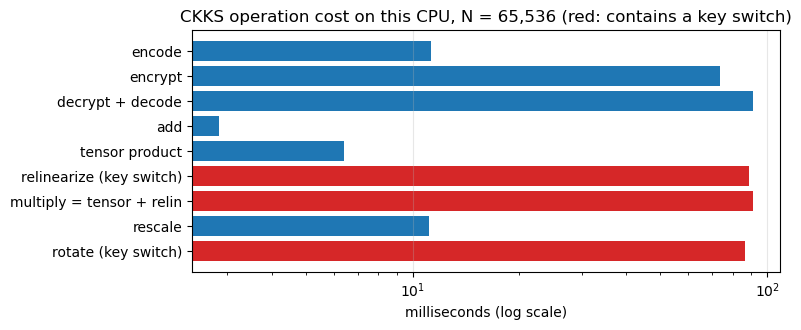

In [120]:
cc16 = make_context(depth=20, technique=fhe.ScalingTechnique.FIXEDMANUAL)
he16 = CKKS(cc16, rotations=[1])
N16 = cc16.GetRingDimension()
v = rng.uniform(-1, 1, N16 // 2)
pt16 = cc16.MakeCKKSPackedPlaintext(list(v))
c16 = cc16.Encrypt(he16.keys.publicKey, pt16)
tensor = cc16.EvalMultNoRelin(c16, c16)
product = cc16.EvalMult(c16, c16)

timings = {                                              # name: (ms on this CPU, Cheddar RTX 4090 in ms or None)
    "encode":                    (median_ms(lambda: cc16.MakeCKKSPackedPlaintext(list(v))), None),
    "encrypt":                   (median_ms(lambda: cc16.Encrypt(he16.keys.publicKey, pt16)), None),
    "decrypt + decode":          (median_ms(lambda: cc16.Decrypt(c16, he16.keys.secretKey)), None),
    "add":                       (median_ms(lambda: cc16.EvalAdd(c16, c16), 20), 0.048),
    "tensor product":            (median_ms(lambda: cc16.EvalMultNoRelin(c16, c16)), None),
    "relinearize (key switch)":  (median_ms(lambda: cc16.Relinearize(tensor)), None),
    "multiply = tensor + relin": (median_ms(lambda: cc16.EvalMult(c16, c16)), 0.533),
    "rescale":                   (median_ms(lambda: cc16.Rescale(product)), 0.068),
    "rotate (key switch)":       (median_ms(lambda: cc16.EvalRotate(c16, 1)), 0.476),
}
print(f"N = {N16:,}, L = 21 limbs, {os.cpu_count()} CPU cores\n")
print_table(["operation", "this CPU (ms)", "RTX 4090, Cheddar (ms)", "GPU speedup"],
            [(name, cpu, gpu, None if gpu is None else f"{cpu / gpu:,.0f}x") for name, (cpu, gpu) in timings.items()],
            ["", ".1f", ".3f", ""])
plot_timings(timings, N16)

The pattern matches the slides. Element-wise work (add, tensor product) is cheap, rescale costs NTTs on
every limb, and anything with a **key switch** (relinearize, rotate) is an order of magnitude more.
A modern GPU library is about two orders of magnitude (roughly 100–270$\times$) faster on the same kinds of operations.

## <a id="s4-6"></a>4.6 Bootstrapping

Bootstrapping homomorphically evaluates decryption to refill the modulus chain. It needs its own set of
rotation keys and a deep chain. With 8 GB of RAM this laptop can only bootstrap small, **insecure** rings
(`HEStd_NotSet`, as in OpenFHE's own `simple-ckks-bootstrapping` example). At 128-bit security bootstrapping needs
$N\ge2^{16}$ and several GB of keys, thousands of times the 256 KiB message they serve (32,768 float64 slots).
That is exactly the memory wall of the *CKKS on GPUs* section.

In [121]:
print_table(["N", "depth", "keygen", "message", "bootstrap keys", "keys vs message", "bootstrap",
             "levels left: before -> after", "correct bits"],
            [bootstrap_demo(log_n) for log_n in (12, 13)], [",", "", "", "", "", "", "", "", ""])

    N | depth | keygen |  message | bootstrap keys | keys vs message | bootstrap | levels left: before -> after | correct bits
------+-------+--------+----------+----------------+-----------------+-----------+------------------------------+-------------
4,096 |    32 |   1.2s | 16.0 KiB |        314 MiB |         20,085x |     0.87s |                      1 -> 10 |         15.8
8,192 |    32 |   1.4s | 32.0 KiB |        512 MiB |         16,377x |     2.14s |                      1 -> 10 |         14.6
